In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
from pyspark.sql import functions as F

from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from yellowbrick.model_selection import FeatureImportances

import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

In [2]:
from pyspark.sql import SparkSession
import os
def get_loading_spark(app_name="Data_Loader"):
    os.environ["OCI_IAM_TYPE"] = "resource_principal"

    spark = (SparkSession.builder
        .appName(app_name)
        .master("local[10]")      
        .config("spark.driver.memory", "15g") 
        .config("spark.driver.maxResultSize", "10g")        
        .config("spark.hadoop.fs.oci.client.auth.kind", "resource_principal")
        .config("spark.hadoop.fs.oci.client.regionCodeOrId", "us-chicago-1")
        .getOrCreate())    

    hadoop_conf = spark.sparkContext._jsc.hadoopConfiguration()
    hadoop_conf.set("fs.oci.client.auth.kind", "resource_principal")
    hadoop_conf.set("fs.oci.client.regionCodeOrId", "us-chicago-1")
    hadoop_conf.set("fs.oci.client.custom.authenticator",
                    "com.oracle.bmc.hdfs.auth.ResourcePrincipalsCustomAuthenticator")

    return spark

spark = get_loading_spark()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/12 01:54:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
dfs = {}
base_uri = "oci://layer-gold@axshbddfc2lf/"

pastas_gold = [
    'score-01',
    'plus-score-02',
    'plus-telco',
    'Plus-cadastro',
    'Plus-recarga',
    'abt-final'
]

print('--- 📂 Iniciando Leitura Direta do Object Storage ---')

for tabela in pastas_gold:
    path_completo = f"{base_uri}{tabela}"
    print(f'📖 Lendo: {tabela}...')

    # O Spark identifica automaticamente as subpastas (partições)
    # de tabela-recarga e tabela-cadastral
    dfs[tabela] = spark.read.parquet(path_completo)


--- 📂 Iniciando Leitura Direta do Object Storage ---
📖 Lendo: score-01...


26/03/12 01:55:06 WARN ObjectStorageClient: Warning for OCI SDK usage with the Apache Connector (the OCI SDK uses the Apache Connector by default, for HTTP calls): the following operations of ObjectStorageClient return a stream : [getObject]. If using Apache Connector, make sure to close all stream instances returned by the operation(s) mentioned, explicitly, by calling 'close' to release the connection back to the connection pool and avoid any indefinite hangs, or read the stream completely. The stream instances are wrapped in an auto closeable stream, to disable this setting or for guidance on disabling this warning, possible performance optimizations, or disabling use of the Apache Connector in the OCI SDK, please see?https://github.com/oracle/oci-java-sdk/blob/master/ApacheConnector-README.md
                                                                                

📖 Lendo: plus-score-02...
📖 Lendo: plus-telco...
📖 Lendo: Plus-cadastro...
📖 Lendo: Plus-recarga...


📖 Lendo: abt-final...


In [5]:
# ==========================================
# 1. REGRAS DE NEGÓCIO E CONFIGURAÇÕES
# ==========================================
BENCHMARK_KS = 33.1
TARGET = 'FPD'
FLAG_OOT = 'Flag_OOT'           
FLAG_CONTROLE = 'GRUPO_CONTROLE' 
COLUNA_SAFRA = 'SAFRA'        

COLUNAS_IGNORADAS = [
    TARGET, FLAG_OOT, FLAG_CONTROLE, COLUNA_SAFRA, 
    'NUM_CPF', 'ID_UNICO'
]

ETAPAS_INCREMENTAIS = {
    1: {'nome': 'Score 1', 'chave_df': 'score-01'},
    2: {'nome': 'Score 2', 'chave_df': 'plus-score-02'},
    3: {'nome': 'Telco', 'chave_df': 'plus-telco'},
    4: {'nome': 'Cadastral', 'chave_df': 'Plus-cadastro'},
    5: {'nome': 'Recarga', 'chave_df': 'Plus-recarga'},
    6: {'nome': 'Pagamento (ABT Final)', 'chave_df': 'abt-final'}
}

In [6]:
# ==========================================
# 2. FUNÇÕES AUXILIARES (MÉTRICAS E GRÁFICOS)
# ==========================================

def calcular_metricas(y_true, y_pred_proba, threshold=0.5):
    """Calcula todas as métricas exigidas para o modelo de crédito."""
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = (2 * auc - 1) * 100
    
    y_pred = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Cálculo preciso do KS
    df_ks = pd.DataFrame({'target': y_true, 'proba': y_pred_proba})
    df_ks = df_ks.sort_values(by='proba', ascending=False)
    df_ks['cum_bads'] = df_ks['target'].cumsum() / df_ks['target'].sum()
    df_ks['cum_goods'] = (1 - df_ks['target']).cumsum() / (len(df_ks) - df_ks['target'].sum())
    ks = np.max(np.abs(df_ks['cum_bads'] - df_ks['cum_goods'])) * 100
    
    return {'KS': ks, 'Gini': gini, 'AUC': auc, 'Recall': recall, 'Precision': precision, 'F1': f1}

def plotar_roc_comparativa(model, X_train, y_train, X_oot, y_oot, X_ctrl, y_ctrl, titulo):
    """Gera o gráfico de Curva ROC comparando as três visões."""
    plt.figure(figsize=(8, 6))
    
    for nome, X, y in [('Treino', X_train, y_train), ('OOT', X_oot, y_oot), ('Controle', X_ctrl, y_ctrl)]:
        if len(y) > 0:
            proba = model.predict_proba(X)[:, 1]
            fpr, tpr, _ = roc_curve(y, proba)
            auc_val = roc_auc_score(y, proba)
            plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc_val:.3f})')
            
    plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.500)')
    plt.title(f'Curva ROC Comparativa - {titulo}')
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

def plotar_matriz_confusao(y_true, y_pred_proba, threshold=0.5, titulo="Matriz de Confusão (OOT)"):
    """Plota um Heatmap elegante da Matriz de Confusão."""
    
    y_pred = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Bom Pagador (0)', 'Mau Pagador (1)'],
                yticklabels=['Bom Pagador (0)', 'Mau Pagador (1)'])
    plt.title(titulo, fontsize=14, pad=15)
    plt.ylabel('Realidade (O que aconteceu)', fontsize=12)
    plt.xlabel('Predição do Modelo (O que o modelo achou)', fontsize=12)
    plt.tight_layout()
    plt.show()

def plotar_evolucao_ks(df_resultados, benchmark=33.1):
    """Plota a evolução do KS etapa por etapa, evidenciando o Delta."""
    plt.figure(figsize=(10, 6))
    
    # Usando barplot do seaborn
    ax = sns.barplot(data=df_resultados, x='Nome', y='KS', palette='viridis')
    plt.axhline(y=benchmark, color='r', linestyle='--', linewidth=2, label=f'Benchmark exigido ({benchmark})')
    
    # Adicionando os valores em cima de cada barra com o delta colorido
    for index, row in df_resultados.iterrows():
        ks_val = row['KS']
        delta = ks_val - benchmark
        cor_texto = 'green' if delta >= 0 else 'red'
        sinal = '+' if delta >= 0 else ''
        
        # Texto principal (KS) e subtítulo (Delta)
        ax.text(index, ks_val + 0.5, f'{ks_val:.2f}\n({sinal}{delta:.2f})', 
                color=cor_texto, ha="center", fontweight='bold', fontsize=10)

    plt.title('Evolução Incremental do KS (OOT)', fontsize=14, pad=15)
    plt.xlabel('Book de Variáveis (Etapas)', fontsize=12)
    plt.ylabel('KS (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.ylim(0, max(df_resultados['KS'].max() + 5, benchmark + 5))
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# ==========================================
# 2. FUNÇÕES AUXILIARES (MÉTRICAS E GRÁFICOS)
# ==========================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from IPython.display import display

def calcular_metricas(y_true, y_pred_proba, threshold=0.5):
    """Calcula todas as métricas exigidas para o modelo de crédito."""
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = (2 * auc - 1) * 100
    
    y_pred = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    df_ks = pd.DataFrame({'target': y_true, 'proba': y_pred_proba})
    df_ks = df_ks.sort_values(by='proba', ascending=False)
    df_ks['cum_bads'] = df_ks['target'].cumsum() / df_ks['target'].sum()
    df_ks['cum_goods'] = (1 - df_ks['target']).cumsum() / (len(df_ks) - df_ks['target'].sum())
    ks = np.max(np.abs(df_ks['cum_bads'] - df_ks['cum_goods'])) * 100
    
    return {'KS': ks, 'Gini': gini, 'AUC': auc, 'Recall': recall, 'Precision': precision, 'F1': f1}

def plotar_roc_comparativa(model, X_train, y_train, X_te, y_te, X_ctrl, y_ctrl, titulo, caminho_salvar=None):
    """Gera o gráfico de Curva ROC comparando Treino, Teste e Controle."""
    plt.figure(figsize=(8, 6))
    
    # Atualizado 'OOT' para 'Teste' conforme solicitado
    for nome, X, y in [('Treino', X_train, y_train), ('Teste', X_te, y_te), ('Controle', X_ctrl, y_ctrl)]:
        if len(y) > 0:
            proba = model.predict_proba(X)[:, 1]
            fpr, tpr, _ = roc_curve(y, proba)
            auc_val = roc_auc_score(y, proba)
            plt.plot(fpr, tpr, label=f'{nome} (AUC = {auc_val:.3f})', lw=2)
            
    plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.500)')
    plt.title(f'Curva ROC Comparativa - {titulo}', fontsize=14, pad=15)
    plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=12)
    plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)', fontsize=12)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if caminho_salvar:
        plt.savefig(os.path.join(caminho_salvar, '02_roc_comparativa_geral.png'), dpi=300, bbox_inches='tight')
    plt.show()

def plotar_matriz_confusao(y_true, y_pred_proba, threshold=0.5, titulo="Matriz de Confusão", caminho_salvar=None):
    """Plota um Heatmap da Matriz de Confusão."""
    y_pred = (y_pred_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Bom Pagador (0)', 'Mau Pagador (1)'],
                yticklabels=['Bom Pagador (0)', 'Mau Pagador (1)'])
    plt.title(titulo, fontsize=14, pad=15)
    plt.ylabel('Realidade', fontsize=12)
    plt.xlabel('Predição do Modelo', fontsize=12)
    plt.tight_layout()
    
    if caminho_salvar:
        plt.savefig(os.path.join(caminho_salvar, '01_matriz_confusao.png'), dpi=300, bbox_inches='tight')
    plt.show()

--- 1. EXTRAINDO METADADOS DO SPARK ---
Etapa 'score-01': 5 features mapeadas.
Etapa 'plus-score-02': 8 features mapeadas.
Etapa 'plus-telco': 80 features mapeadas.
Etapa 'Plus-cadastro': 272 features mapeadas.
Etapa 'Plus-recarga': 358 features mapeadas.
Etapa 'abt-final': 407 features mapeadas.

--- 2. AMOSTRAGEM ESTRATIFICADA NATIVA E CARGA DA ABT ---


Classes identificadas nativamente no Spark para estratificação: ['0', '1']
Calculando proporção original de FPD no cluster Spark...


Baixando amostra de 35.0% para a RAM local (Pandas)...


26/03/12 01:56:20 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                


Sucesso! ABT Final carregada com segurança.
Shape final: 944078 linhas e 413 colunas.


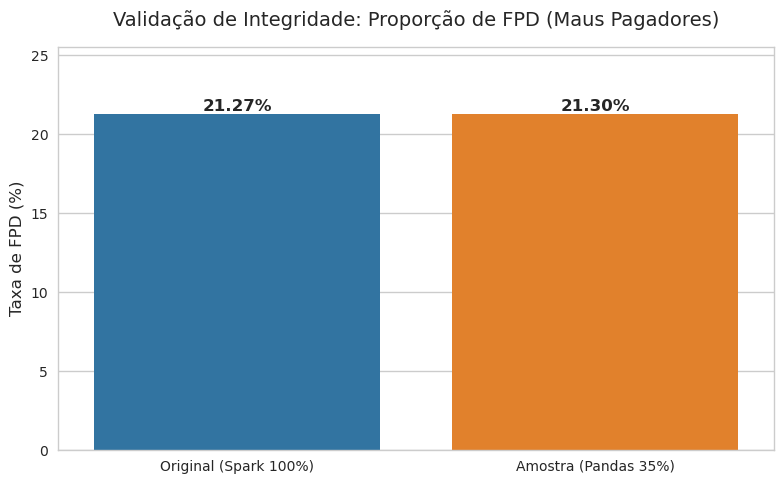

In [7]:
# ==========================================
# 3. EXTRAÇÃO DE METADADOS E CARGA DA ABT
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. EXTRAINDO METADADOS DO SPARK ---")
features_por_etapa = {}
FRACAO_SPARK = 0.35

# Mapeia as colunas de cada etapa lendo direto do dicionário 'dfs' (Spark)
for chave, df_spark in dfs.items():
    colunas_validas = [col for col in df_spark.columns if col not in COLUNAS_IGNORADAS]
    features_por_etapa[chave] = colunas_validas
    print(f"Etapa '{chave}': {len(colunas_validas)} features mapeadas.")

print("\n--- 2. AMOSTRAGEM ESTRATIFICADA NATIVA E CARGA DA ABT ---")
df_spark_abt = dfs['abt-final']

# Passo A: Extração Dinâmica das Chaves (A forma mais elegante e segura no PySpark)
# O Spark descobre sozinho quais são as classes e os tipos exatos da coluna TARGET
chaves_target = [row[TARGET] for row in df_spark_abt.select(TARGET).distinct().collect() if row[TARGET] is not None]

# Monta o dicionário de frações programaticamente
fracoes_exatas = {chave: FRACAO_SPARK for chave in chaves_target}
print(f"Classes identificadas nativamente no Spark para estratificação: {chaves_target}")

# Passo B: Calcular a distribuição ORIGINAL no Spark (antes de amostrar)
print("Calculando proporção original de FPD no cluster Spark...")
dist_spark = df_spark_abt.groupBy(TARGET).count().toPandas()
dist_spark['percentual'] = (dist_spark['count'] / dist_spark['count'].sum()) * 100

#.astype(str) apenas para a busca, garantindo que acharemos o "1" independente do tipo original
taxa_fpd_original = dist_spark.loc[dist_spark[TARGET].astype(str) == '1', 'percentual'].values[0]

# Passo C: Amostragem estratificada e conversão
print(f"Baixando amostra de {FRACAO_SPARK*100}% para a RAM local (Pandas)...")
df_abt_amostrada = df_spark_abt.sampleBy(TARGET, fractions=fracoes_exatas, seed=42)
df_abt_pandas = df_abt_amostrada.toPandas()

# Forçr a conversão para inteiro no Pandas para garantir compatibilidade com o XGBoost depois
df_abt_pandas[TARGET] = df_abt_pandas[TARGET].astype(int)

# Passo D: Calcular a distribuição na AMOSTRA (Pandas)
taxa_fpd_amostra = (df_abt_pandas[TARGET] == 1).mean() * 100

print(f"\nSucesso! ABT Final carregada com segurança.")
print(f"Shape final: {df_abt_pandas.shape[0]} linhas e {df_abt_pandas.shape[1]} colunas.")

# ==========================================
# 3.1 VISUALIZAÇÃO DA INTEGRIDADE DA AMOSTRA
# ==========================================

plt.figure(figsize=(8, 5))
barras = sns.barplot(
    x=['Original (Spark 100%)', f'Amostra (Pandas {FRACAO_SPARK*100:.0f}%)'], 
    y=[taxa_fpd_original, taxa_fpd_amostra],
    palette=['#1f77b4', '#ff7f0e']
)

# Adicionando os rótulos de dados no topo das barras para clareza
for p in barras.patches:
    barras.annotate(f'{p.get_height():.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Validação de Integridade: Proporção de FPD (Maus Pagadores)', fontsize=14, pad=15)
plt.ylabel('Taxa de FPD (%)', fontsize=12)
plt.ylim(0, max(taxa_fpd_original, taxa_fpd_amostra) * 1.2) # Dá um respiro visual no topo para o número não cortar
plt.tight_layout()
plt.show()

In [8]:
# ==========================================
# 3.5 HIGIENIZAÇÃO E CONVERSÃO DE TIPOS
# ==========================================
import pandas as pd

print("--- INICIANDO CONVERSÃO DE COLUNAS 'OBJECT' PARA NUMÉRICAS ---")

# Identifica todas as colunas que são features (ignorando as chaves de negócio)
colunas_features = [col for col in df_abt_pandas.columns if col not in COLUNAS_IGNORADAS]

contador_convertidas = 0

# Percorre as features e força a conversão das que estão como texto/object
for col in colunas_features:
    if df_abt_pandas[col].dtype == 'object':
        # errors='coerce' transforma textos puros (ex: "missing") em NaN (Nulo), que o XGBoost aceita
        df_abt_pandas[col] = pd.to_numeric(df_abt_pandas[col], errors='coerce')
        contador_convertidas += 1

print(f"Sucesso! {contador_convertidas} colunas foram convertidas de texto para número.")
print("A ABT está higienizada e pronta para o XGBoost.")

--- INICIANDO CONVERSÃO DE COLUNAS 'OBJECT' PARA NUMÉRICAS ---
Sucesso! 69 colunas foram convertidas de texto para número.
A ABT está higienizada e pronta para o XGBoost.


In [9]:
# ==========================================
# 4. FUNÇÃO DE TREINAMENTO INCREMENTAL (VERSÃO 2.0 - VISUAL)
# ==========================================
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from IPython.display import display
import pandas as pd
import numpy as np

def executar_incremental(df_abt, dic_features, modelo_escolhido='xgb', features_excluir=None, caminho_salvar_graficos=None):
    if features_excluir is None:
        features_excluir = []
        
    # Garante que a pasta de gráficos exista
    if caminho_salvar_graficos:
        os.makedirs(caminho_salvar_graficos, exist_ok=True)
        print(f"📁 Os gráficos serão salvos em: {caminho_salvar_graficos}")
        
    print(f"\n--- INICIANDO MODELAGEM INCREMENTAL ({modelo_escolhido.upper()}) ---")
    
    resultados_evolucao = []
    modelo_final_treinado = None
    ultima_etapa = max(ETAPAS_INCREMENTAIS.keys())
    
    df_controle = df_abt[df_abt[FLAG_CONTROLE] == 1]
    df_modelagem = df_abt[df_abt[FLAG_CONTROLE] == 0]
    
    df_oot = df_modelagem[df_modelagem[FLAG_OOT] == 1]
    df_treino = df_modelagem[df_modelagem[FLAG_OOT] == 0]
    
    ks_anterior = 0.0 
    
    for etapa, config in ETAPAS_INCREMENTAIS.items():
        nome_etapa = config['nome']
        chave = config['chave_df']
        
        if chave not in dic_features:
            print(f"⚠️ Aviso: Features da tabela '{chave}' não mapeadas. Pulando etapa {etapa}.")
            continue
        
        features_atuais = [f for f in dic_features[chave] if f not in features_excluir]
        print(f"\n" + "="*60)
        print(f"🚀 ETAPA {etapa}: {nome_etapa} ({len(features_atuais)} variáveis)")
        print("="*60)
        
        X_train, y_train = df_treino[features_atuais], df_treino[TARGET]
        X_oot, y_oot = df_oot[features_atuais], df_oot[TARGET]
        X_ctrl, y_ctrl = df_controle[features_atuais], df_controle[TARGET]
        
        if modelo_escolhido == 'xgb':
            clf = XGBClassifier(
                n_estimators=200, learning_rate=0.05, max_depth=5, 
                objective="binary:logistic", tree_method="hist", 
                random_state=42, n_jobs=-1
            )
        elif modelo_escolhido == 'gb':
            clf = GradientBoostingClassifier(
                n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42
            )
            
        clf.fit(X_train, y_train)
        
        proba_train = clf.predict_proba(X_train)[:, 1]
        proba_oot = clf.predict_proba(X_oot)[:, 1]
        
        metricas_oot = calcular_metricas(y_oot, proba_oot)
        ks_atual = metricas_oot['KS']
        delta_ks = ks_atual - ks_anterior
        
        print(f"KS Teste: {ks_atual:.2f}% (Ganho: {delta_ks:+.2f}) | AUC: {metricas_oot['AUC']:.4f}")
        
        # Plot Acompanhamento da Etapa
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        fpr_tr, tpr_tr, _ = roc_curve(y_train, proba_train)
        auc_tr = roc_auc_score(y_train, proba_train)
        fpr_te, tpr_te, _ = roc_curve(y_oot, proba_oot)
        
        axes[0].plot(fpr_tr, tpr_tr, label=f'Treino (AUC = {auc_tr:.3f})', color='#1f77b4', lw=2)
        axes[0].plot(fpr_te, tpr_te, label=f'Teste (AUC = {metricas_oot["AUC"]:.3f})', color='#ff7f0e', lw=2)
        axes[0].plot([0, 1], [0, 1], 'k--')
        axes[0].set_title(f'Curva ROC - {nome_etapa}')
        axes[0].legend(loc='lower right')
        axes[0].grid(True, alpha=0.3)
        
        cores_barras = ['#d3d3d3', '#2ca02c' if delta_ks >= 0 else '#d62728']
        sns.barplot(x=['Etapa Anterior', 'Etapa Atual'], y=[ks_anterior, ks_atual], ax=axes[1], palette=cores_barras)
        axes[1].axhline(y=BENCHMARK_KS, color='r', linestyle='--', label=f'Benchmark ({BENCHMARK_KS})')
        axes[1].set_title(f'Salto do KS: {delta_ks:+.2f} pontos')
        axes[1].legend(loc='lower right')
        
        for i, v in enumerate([ks_anterior, ks_atual]):
            axes[1].text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')
            
        plt.tight_layout()
        if caminho_salvar_graficos:
            plt.savefig(os.path.join(caminho_salvar_graficos, f'loop_etapa_{etapa}_{nome_etapa}.png'), dpi=200, bbox_inches='tight')
        plt.show()
        
        ks_anterior = ks_atual
        
        resultados_evolucao.append({
            'Etapa': etapa, 'Nome': nome_etapa, 'Features': len(features_atuais), **metricas_oot
        })
        
        # ---------------------------------------------------------
        # DOSSIÊ FINAL (Na última etapa do loop)
        # ---------------------------------------------------------
        if etapa == ultima_etapa:
            modelo_final_treinado = clf
            print("\n" + "★"*60)
            print("DOSSIÊ DE VALIDAÇÃO FINAL (ABT COMPLETADA)")
            print("★"*60)
            
            # 1. Matriz de Confusão
            plotar_matriz_confusao(y_oot, proba_oot, titulo="Matriz de Confusão Final (Teste)", caminho_salvar=caminho_salvar_graficos)
            
            # 2. Curva ROC Comparativa Geral
            plotar_roc_comparativa(clf, X_train, y_train, X_oot, y_oot, X_ctrl, y_ctrl, titulo="Visão Geral do Modelo", caminho_salvar=caminho_salvar_graficos)
            
            # 3. ROC Controle (Modelo vs Scores de Mercado)
            plt.figure(figsize=(10, 6))
            proba_ctrl_mod = clf.predict_proba(X_ctrl)[:, 1]
            fpr_mod, tpr_mod, _ = roc_curve(y_ctrl, proba_ctrl_mod)
            auc_mod = roc_auc_score(y_ctrl, proba_ctrl_mod)
            plt.plot(fpr_mod, tpr_mod, label=f'Modelo Final - Controle (AUC = {auc_mod:.3f})', color='#1f77b4', lw=3)
            
            for score_col, cor in [('SCORE_01', '#2ca02c'), ('SCORE_02', '#d62728')]:
                if score_col in df_controle.columns:
                    sc_puro = df_controle[score_col]
                    if roc_auc_score(y_ctrl, sc_puro) < 0.5: sc_puro = -sc_puro
                    fpr_sc, tpr_sc, _ = roc_curve(y_ctrl, sc_puro)
                    auc_sc = roc_auc_score(y_ctrl, sc_puro)
                    plt.plot(fpr_sc, tpr_sc, label=f'{score_col} Puro - Controle (AUC = {auc_sc:.3f})', linestyle='--', color=cor, lw=2)
            
            plt.plot([0, 1], [0, 1], 'k--')
            plt.title('Validação Extrema: Modelo vs Scores no Grupo Controle', fontsize=14, pad=15)
            plt.xlabel('FPR (1 - Especificidade)')
            plt.ylabel('TPR (Sensibilidade)')
            plt.legend(loc='lower right')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            if caminho_salvar_graficos:
                plt.savefig(os.path.join(caminho_salvar_graficos, '03_roc_controle_scores.png'), dpi=300, bbox_inches='tight')
            plt.show()

            # 4. Gráfico de KS Acumulado e Corte Ótimo
            df_ks_plot = pd.DataFrame({'target': y_oot, 'proba': proba_oot}).sort_values(by='proba', ascending=False).reset_index(drop=True)
            df_ks_plot['cum_bads'] = df_ks_plot['target'].cumsum() / df_ks_plot['target'].sum() * 100
            df_ks_plot['cum_goods'] = (1 - df_ks_plot['target']).cumsum() / (len(df_ks_plot) - df_ks_plot['target'].sum()) * 100
            df_ks_plot['ks_dist'] = np.abs(df_ks_plot['cum_bads'] - df_ks_plot['cum_goods'])
            
            ks_max = df_ks_plot['ks_dist'].max()
            ks_idx = df_ks_plot['ks_dist'].idxmax()
            
            plt.figure(figsize=(10, 6))
            eixo_x = np.arange(1, len(df_ks_plot) + 1) / len(df_ks_plot) * 100
            plt.plot(eixo_x, df_ks_plot['cum_bads'], label='Acumulado Inadimplentes (Maus)', color='#ff5a00', lw=3)
            plt.plot(eixo_x, df_ks_plot['cum_goods'], label='Acumulado Adimplentes (Bons)', color='#1c3b5e', lw=3)
            plt.vlines(x=(ks_idx/len(df_ks_plot))*100, ymin=df_ks_plot.loc[ks_idx, 'cum_goods'], ymax=df_ks_plot.loc[ks_idx, 'cum_bads'], color='#2ca02c', linestyle='--', lw=2.5, label=f'KS = {ks_max:.1f}% (Corte Ótimo ~ {(ks_idx/len(df_ks_plot))*100:.1f}%)')
            plt.title('Estatística KS: Validação Pura (ABT Final - Teste)', fontsize=14, pad=15)
            plt.xlabel('População Ordenada por Score (%)')
            plt.ylabel('Proporção Acumulada (%)')
            plt.legend(loc='upper left')
            plt.grid(True, alpha=0.4, linestyle='--')
            plt.tight_layout()
            if caminho_salvar_graficos:
                plt.savefig(os.path.join(caminho_salvar_graficos, '04_ks_acumulado.png'), dpi=300, bbox_inches='tight')
            plt.show()

    # Consolidando resultados
    df_resultados = pd.DataFrame(resultados_evolucao)
    
    # 5. Gráfico de Linha do Crescimento do KS
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df_resultados, x='Nome', y='KS', marker='o', color='#1f77b4', lw=3, markersize=10)
    plt.axhline(y=BENCHMARK_KS, color='r', linestyle='--', lw=2, label=f'Benchmark ({BENCHMARK_KS})')
    plt.title('Crescimento do KS por Tabela Incrementada', fontsize=14, pad=15)
    plt.xlabel('Book de Variáveis (Etapas)', fontsize=12)
    plt.ylabel('KS (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.ylim(0, max(df_resultados['KS'].max() + 5, BENCHMARK_KS + 5))
    
    for i, row in df_resultados.iterrows():
        plt.text(i, row['KS'] + 0.8, f"{row['KS']:.2f}%", ha='center', fontweight='bold', color='black')
        
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if caminho_salvar_graficos:
        plt.savefig(os.path.join(caminho_salvar_graficos, '05_crescimento_ks_linha.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print("\n--- TABELA FINAL DE RESULTADOS ---")
    display(df_resultados)
    
    return df_resultados, modelo_final_treinado


--- INICIANDO MODELAGEM INCREMENTAL (XGB) ---

🚀 ETAPA 1: Score 1 (5 variáveis)
KS Teste: 26.48% (Ganho: +26.48) | AUC: 0.6756


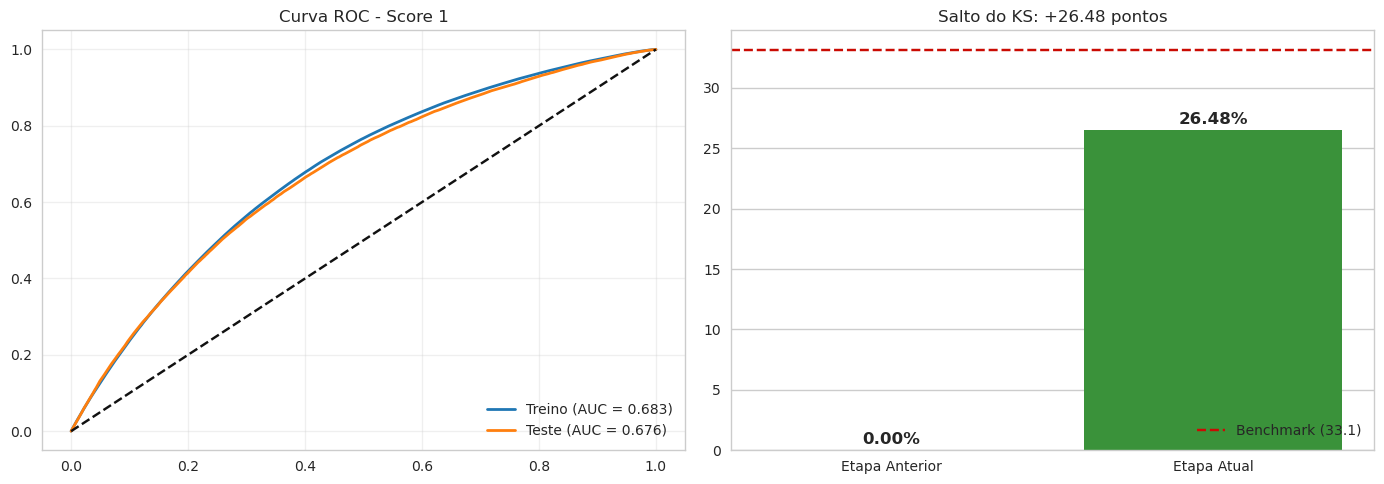


🚀 ETAPA 2: Score 2 (8 variáveis)
KS Teste: 30.72% (Ganho: +4.24) | AUC: 0.7064


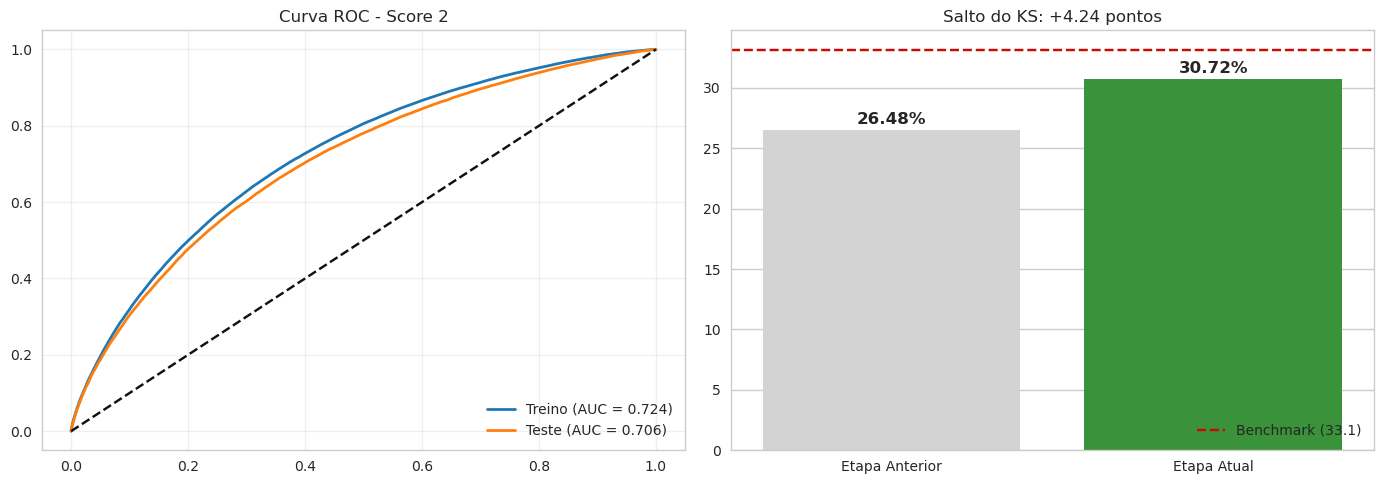


🚀 ETAPA 3: Telco (80 variáveis)
KS Teste: 31.03% (Ganho: +0.31) | AUC: 0.7090


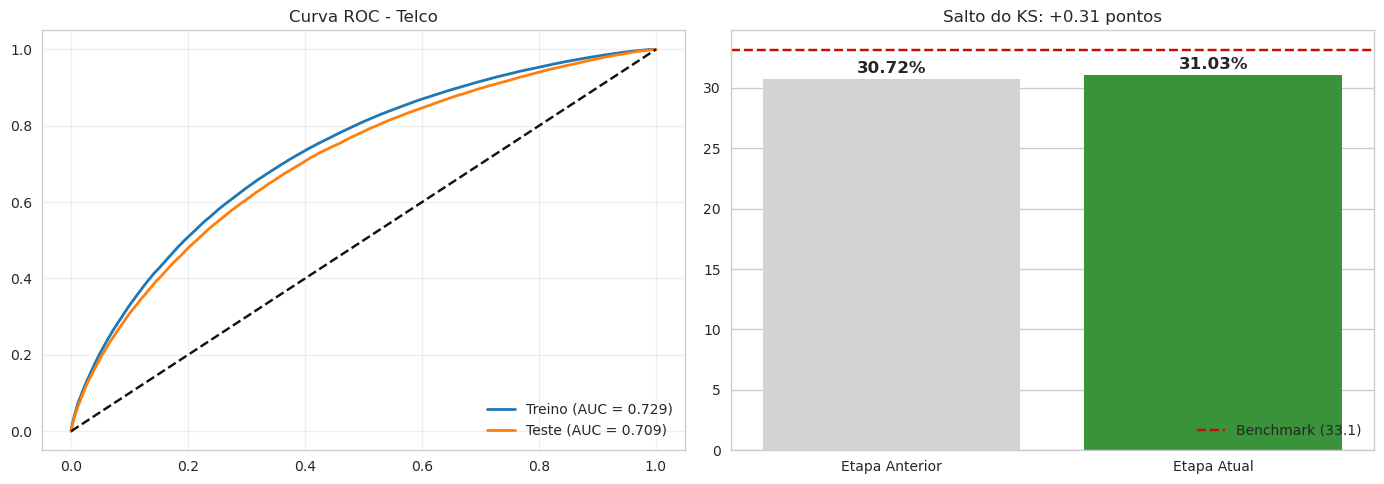


🚀 ETAPA 4: Cadastral (272 variáveis)
KS Teste: 31.18% (Ganho: +0.16) | AUC: 0.7099


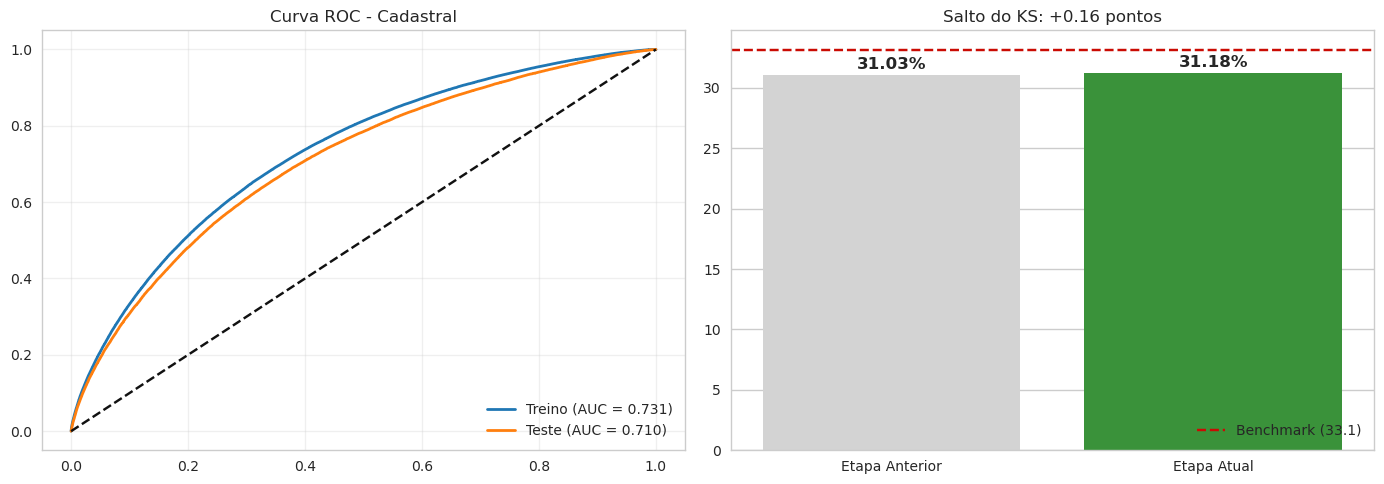


🚀 ETAPA 5: Recarga (358 variáveis)
KS Teste: 34.00% (Ganho: +2.82) | AUC: 0.7282


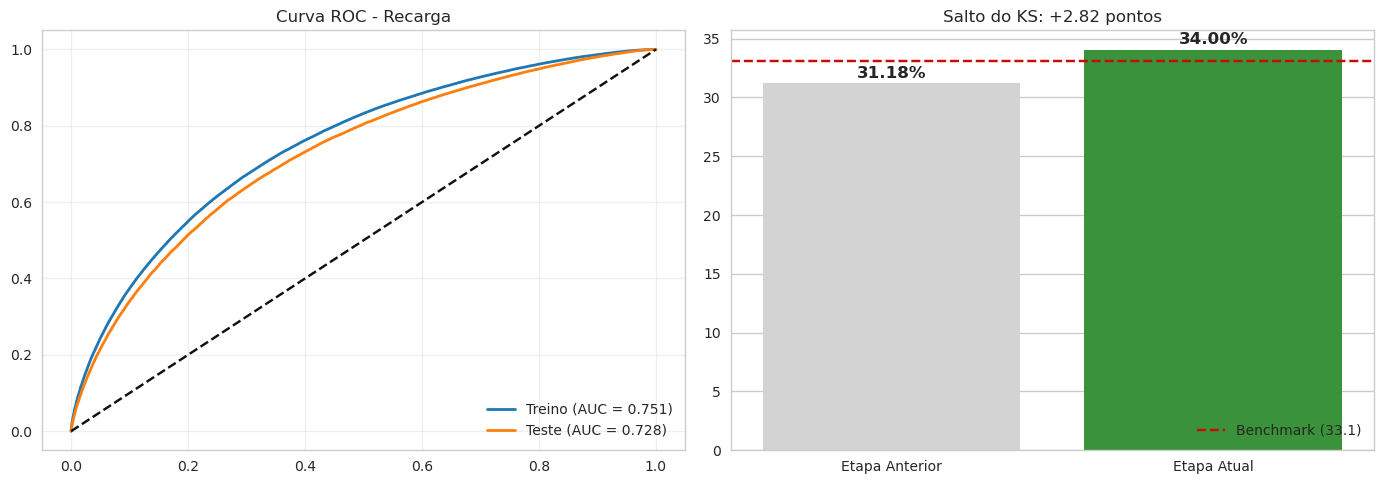


🚀 ETAPA 6: Pagamento (ABT Final) (407 variáveis)
KS Teste: 34.27% (Ganho: +0.27) | AUC: 0.7312


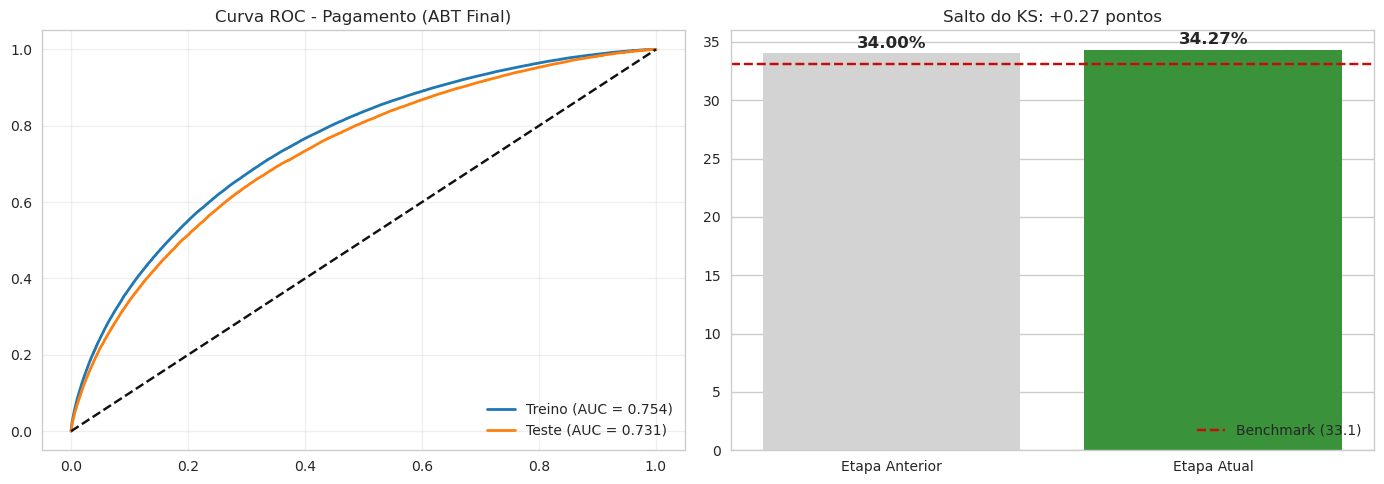


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
DOSSIÊ DE VALIDAÇÃO FINAL (ABT COMPLETADA)
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★


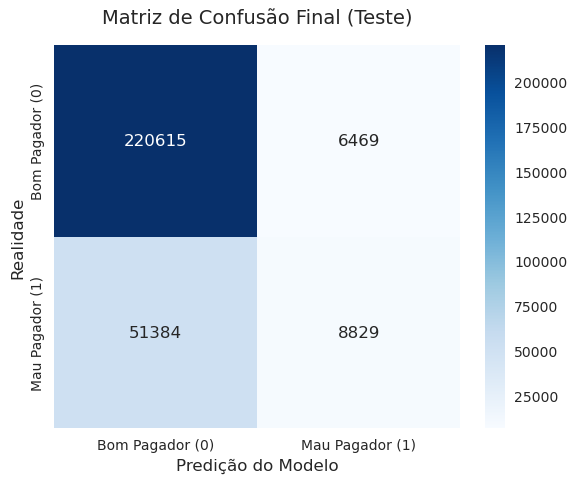

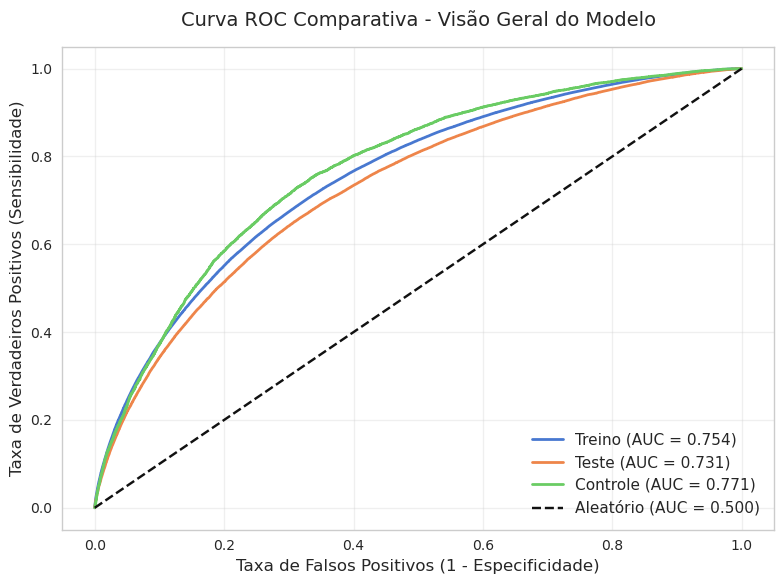

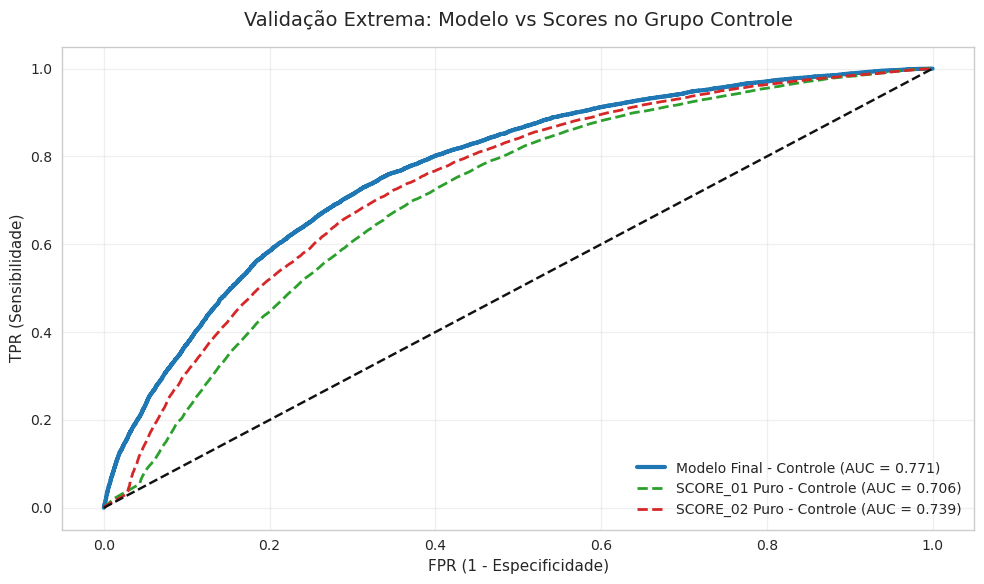

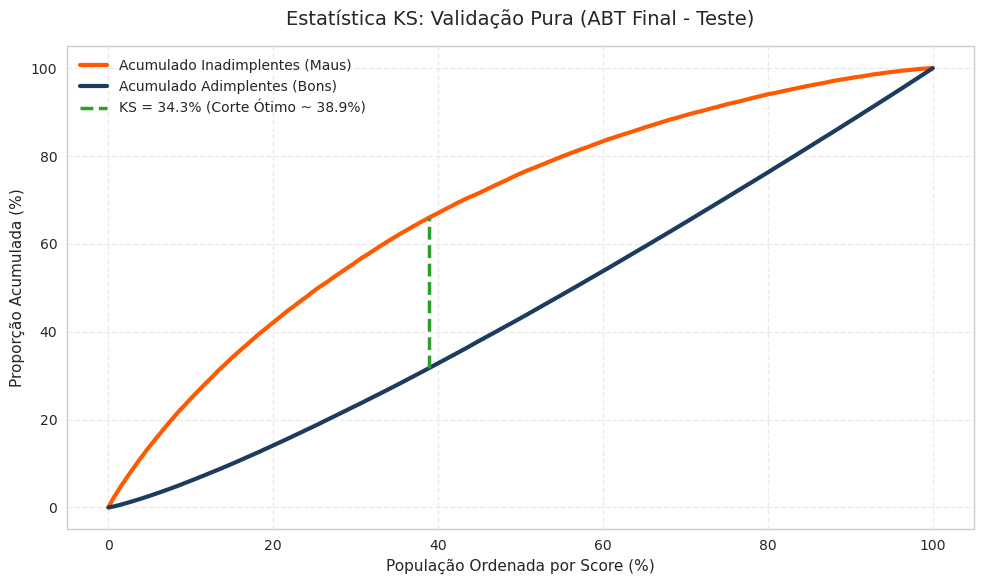

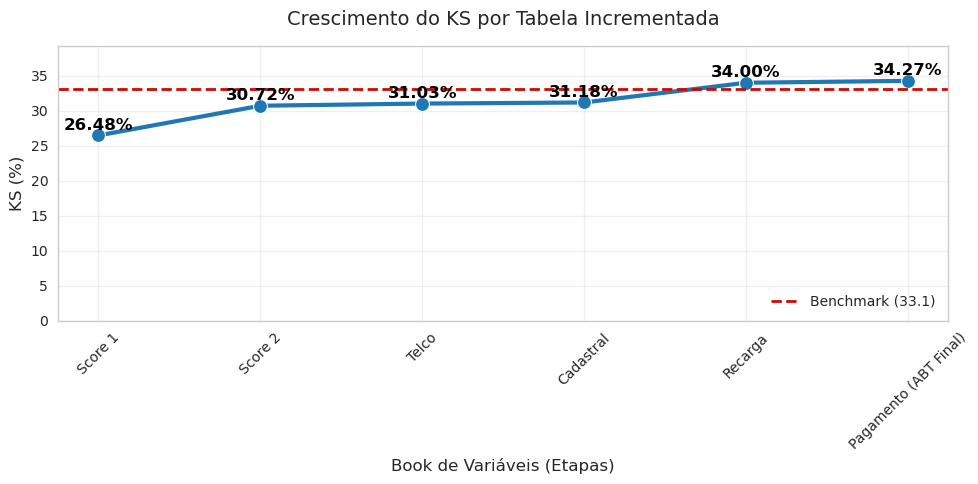


--- TABELA FINAL DE RESULTADOS ---


,Etapa,Nome,Features,KS,Gini,AUC,Recall,Precision,F1
0,1,Score 1,5,26.480386,35.118563,0.675593,0.000000,0.000000,0.000000
1,2,Score 2,8,30.719914,41.275862,0.706379,0.075183,0.574419,0.132963
2,3,Telco,80,31.029627,41.793790,0.708969,0.082922,0.574040,0.144912
3,4,Cadastral,272,31.184720,41.985970,0.709930,0.083803,0.582746,0.146533
4,5,Recarga,358,34.002774,45.637043,0.728185,0.144554,0.574029,0.230949
5,6,Pagamento (ABT Final),407,34.271935,46.238092,0.731190,0.146629,0.577134,0.233847


In [10]:
# ==========================================
# 5. EXECUÇÃO FINAL (VERSÃO 2.0)
# ==========================================

# Aqui nós "capturamos" o modelo que sai da função para a variável modelo_final_treinado
df_resultados_finais, modelo_final_treinado = executar_incremental(
    df_abt=df_abt_pandas, 
    dic_features=features_por_etapa, 
    modelo_escolhido='xgb',
    features_excluir=[] # Se já tiver a lista de variáveis colineares para excluir, coloque aqui
)


--- INICIANDO ANÁLISE DE COLINEARIDADE (ABT FINAL) ---
⚠️ Encontramos 201 variáveis altamente colineares (> 85.0%).


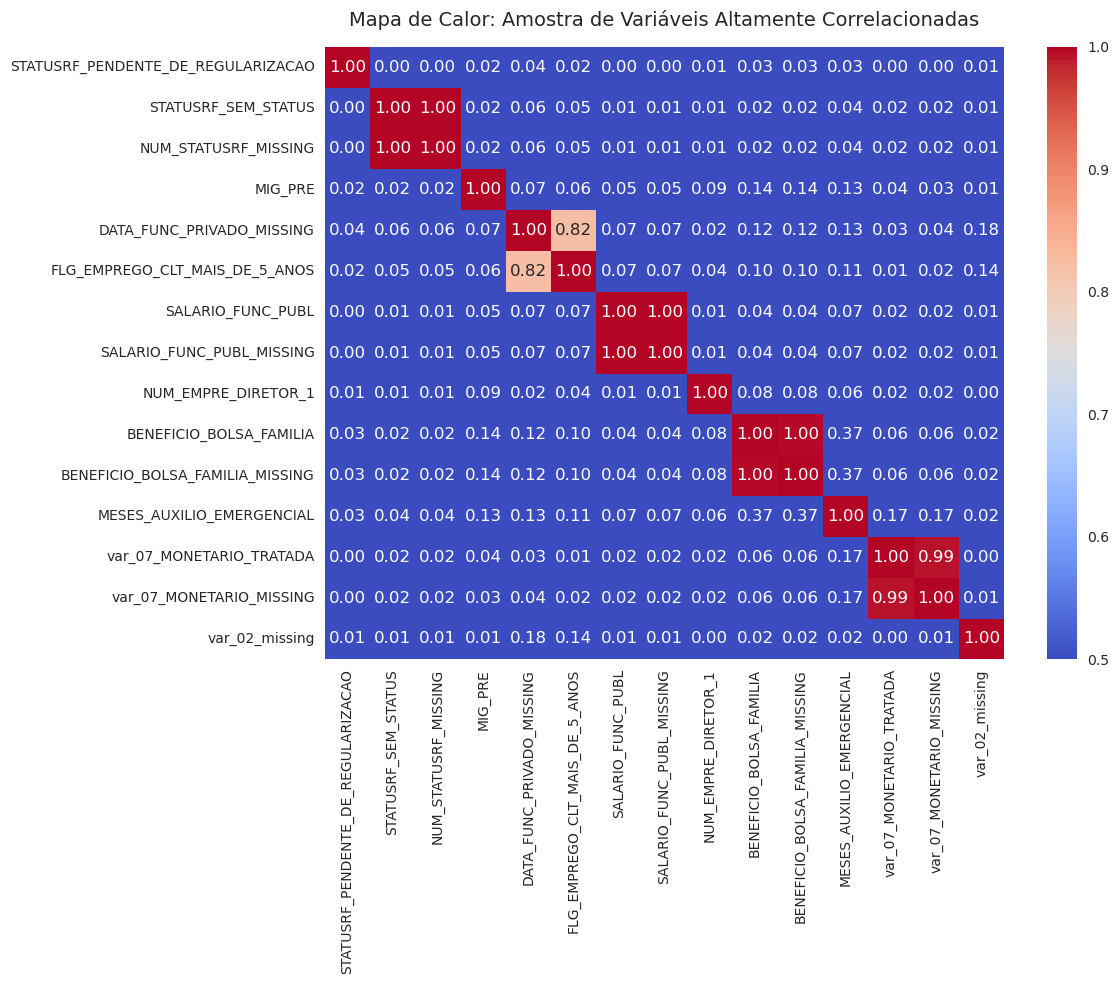


📋 Lista de Colineares Sugeridas para Exclusão (Verifique o SHAP antes de excluir):
['STATUSRF_PENDENTE_DE_REGULARIZACAO', 'STATUSRF_SEM_STATUS', 'NUM_STATUSRF_MISSING', 'MIG_PRE', 'DATA_FUNC_PRIVADO_MISSING', 'FLG_EMPREGO_CLT_MAIS_DE_5_ANOS', 'SALARIO_FUNC_PUBL', 'SALARIO_FUNC_PUBL_MISSING', 'NUM_EMPRE_DIRETOR_1', 'BENEFICIO_BOLSA_FAMILIA', 'BENEFICIO_BOLSA_FAMILIA_MISSING', 'MESES_AUXILIO_EMERGENCIAL', 'var_07_MONETARIO_TRATADA', 'var_07_MONETARIO_MISSING', 'var_02_missing', 'var_26', 'var_27', 'var_28', 'var_29', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_36', 'var_37', 'var_38', 'var_39', 'var_40', 'var_41', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_48', 'var_49', 'var_50', 'var_51', 'var_52', 'var_53', 'var_54', 'var_55', 'var_56', 'var_57', 'var_58', 'var_59', 'var_60', 'var_61', 'var_62', 'var_63', 'var_64', 'var_65', 'var_66', 'var_67', 'var_68', 'var_69', 'var_70', 'var_71', 'var_72', 'var_73', 'var_74', 'var_75', 'var_76', 'var_77'

In [11]:
# ==========================================
# 6. ANÁLISE DE COLINEARIDADE (FILTRO DE REDUNDÂNCIA)
# ==========================================
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os

print("--- INICIANDO ANÁLISE DE COLINEARIDADE (ABT FINAL) ---")

# CORREÇÃO: Declaramos a lista de exclusão aqui. 
# Se você já decidiu quais variáveis jogar fora, coloque os nomes aqui dentro! Ex: ['var_26', 'var_27']
features_excluir = [] 

# Pegamos as features que entraram na última etapa e excluímos as que você já limpou
features_finais = [f for f in features_por_etapa['abt-final'] if f not in features_excluir]

# Usamos apenas o Treino para não vazar informação do Teste/OOT
df_treino_final = df_abt_pandas[(df_abt_pandas[FLAG_OOT] == 0) & (df_abt_pandas[FLAG_CONTROLE] == 0)]

# Amostra de 50.000 linhas para o cálculo ser instantâneo
amostra_corr = df_treino_final[features_finais].sample(min(50000, len(df_treino_final)), random_state=42)

# Calcula a matriz de correlação de Spearman (ideal para crédito/não-linear)
corr_matrix = amostra_corr.corr(method='spearman').abs()

# Pega o triângulo superior da matriz para não contar a mesma dupla duas vezes
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Encontra colunas com correlação acima de 85%
limite_colinearidade = 0.85
colineares = [column for column in upper.columns if any(upper[column] > limite_colinearidade)]

print(f"⚠️ Encontramos {len(colineares)} variáveis altamente colineares (> {limite_colinearidade*100}%).")

# Plot do Mapa de Calor (Amostra das 15 primeiras colineares para não poluir a tela)
if len(colineares) > 0:
    
    plt.figure(figsize=(12, 10))
    cols_to_plot = colineares[:15] 
    sns.heatmap(corr_matrix.loc[cols_to_plot, cols_to_plot], annot=True, cmap='coolwarm', fmt=".2f", vmin=0.5, vmax=1)
    plt.title("Mapa de Calor: Amostra de Variáveis Altamente Correlacionadas", fontsize=14, pad=15)
    plt.tight_layout()
    
    # Se você definiu a pasta de gráficos no Bloco 5, ele salva. Se não, apenas ignora.
    if 'caminho_pasta_graficos' in locals() and caminho_pasta_graficos:
        plt.savefig(os.path.join(caminho_pasta_graficos, '06_matriz_colinearidade.png'), dpi=300, bbox_inches='tight')
    plt.show()

# Imprime a lista completa para você poder copiar e colar na sua regra de exclusão
print("\n📋 Lista de Colineares Sugeridas para Exclusão (Verifique o SHAP antes de excluir):")
print(colineares)

--- INICIANDO ANÁLISE SHAP (A CAIXA PRETA) ---


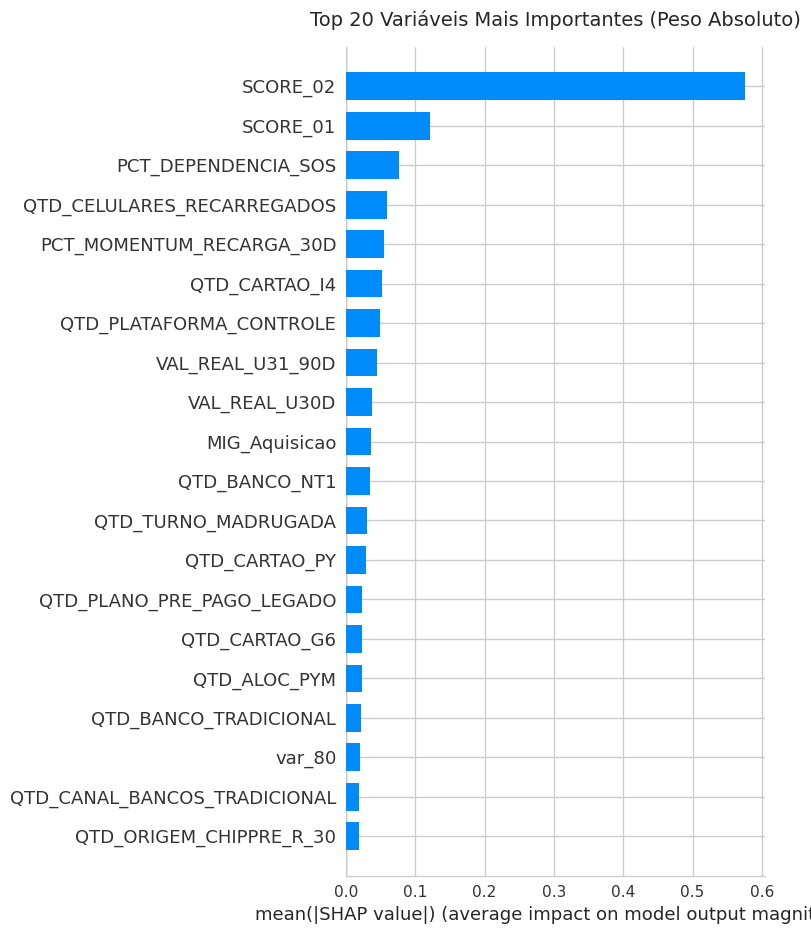


>>> GERANDO O GRÁFICO DIRECIONAL (IMPACTO NO RISCO) <<<


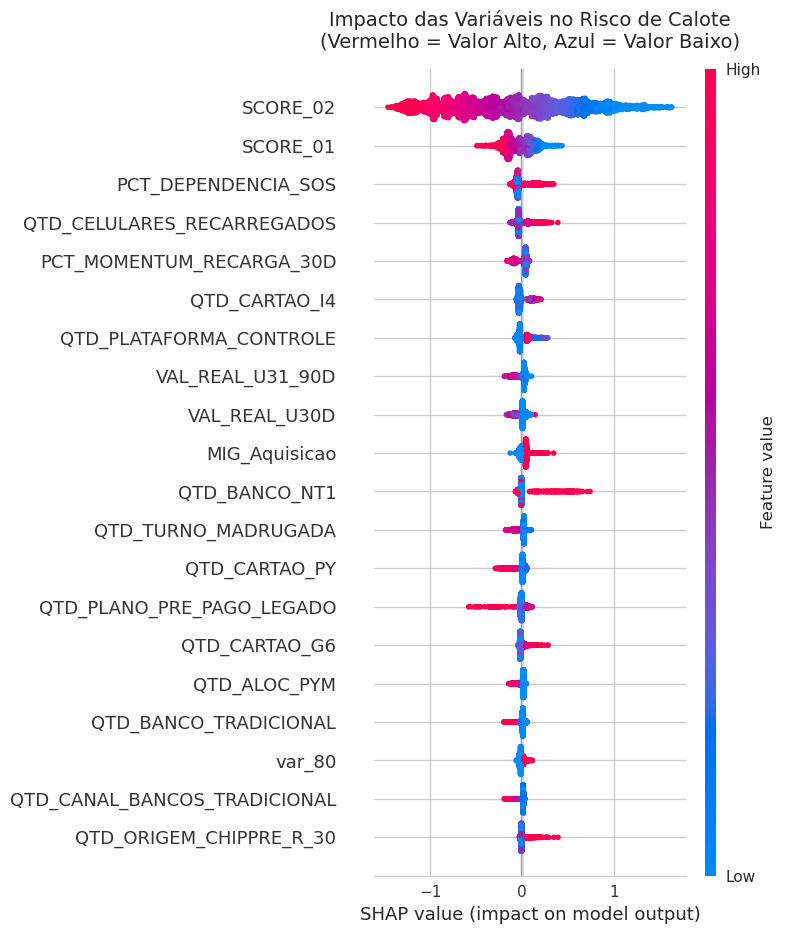

In [12]:
# ==========================================
# 7. EXPLICABILIDADE DO MODELO (SHAP VALUES)
# ==========================================
import shap
import os
import matplotlib.pyplot as plt

print("--- INICIANDO ANÁLISE SHAP (A CAIXA PRETA) ---")
shap.initjs()

# CORREÇÃO: Resgate seguro da variável de diretório
caminho_pasta_graficos = globals().get('caminho_pasta_graficos', 'graficos_hackathon')
if caminho_pasta_graficos:
    os.makedirs(caminho_pasta_graficos, exist_ok=True)

# X_train do modelo final
X_train_final = df_treino_final[features_finais]

# O TreeExplainer extrai a inteligência exata do seu XGBoost treinado
explainer = shap.TreeExplainer(modelo_final_treinado)

# Amostra de 5.000 clientes para renderização rápida no Hackathon
X_amostra_shap = X_train_final.sample(n=min(5000, len(X_train_final)), random_state=42)
shap_values = explainer.shap_values(X_amostra_shap)

# 1. Gráfico de Importância Clássica (Barras)

plt.figure(figsize=(10, 8))
plt.title("Top 20 Variáveis Mais Importantes (Peso Absoluto)", fontsize=14, pad=15)
shap.summary_plot(shap_values, X_amostra_shap, plot_type="bar", max_display=20, show=False)
plt.tight_layout()

if caminho_pasta_graficos:
    plt.savefig(os.path.join(caminho_pasta_graficos, '07_shap_importancia_barras.png'), dpi=300, bbox_inches='tight')
plt.show()

# 2. Gráfico de Impacto Direcional (Summary Plot)
print("\n>>> GERANDO O GRÁFICO DIRECIONAL (IMPACTO NO RISCO) <<<")

plt.figure(figsize=(10, 8))
plt.title("Impacto das Variáveis no Risco de Calote\n(Vermelho = Valor Alto, Azul = Valor Baixo)", fontsize=14, pad=15)
shap.summary_plot(shap_values, X_amostra_shap, max_display=20, show=False)
plt.tight_layout()

if caminho_pasta_graficos:
    plt.savefig(os.path.join(caminho_pasta_graficos, '08_shap_impacto_direcional.png'), dpi=300, bbox_inches='tight')
plt.show()

--- INICIANDO ANÁLISE DE COLINEARIDADE (ABT FINAL) ---
⚠️ Encontramos 201 variáveis altamente colineares (> 85.0%).


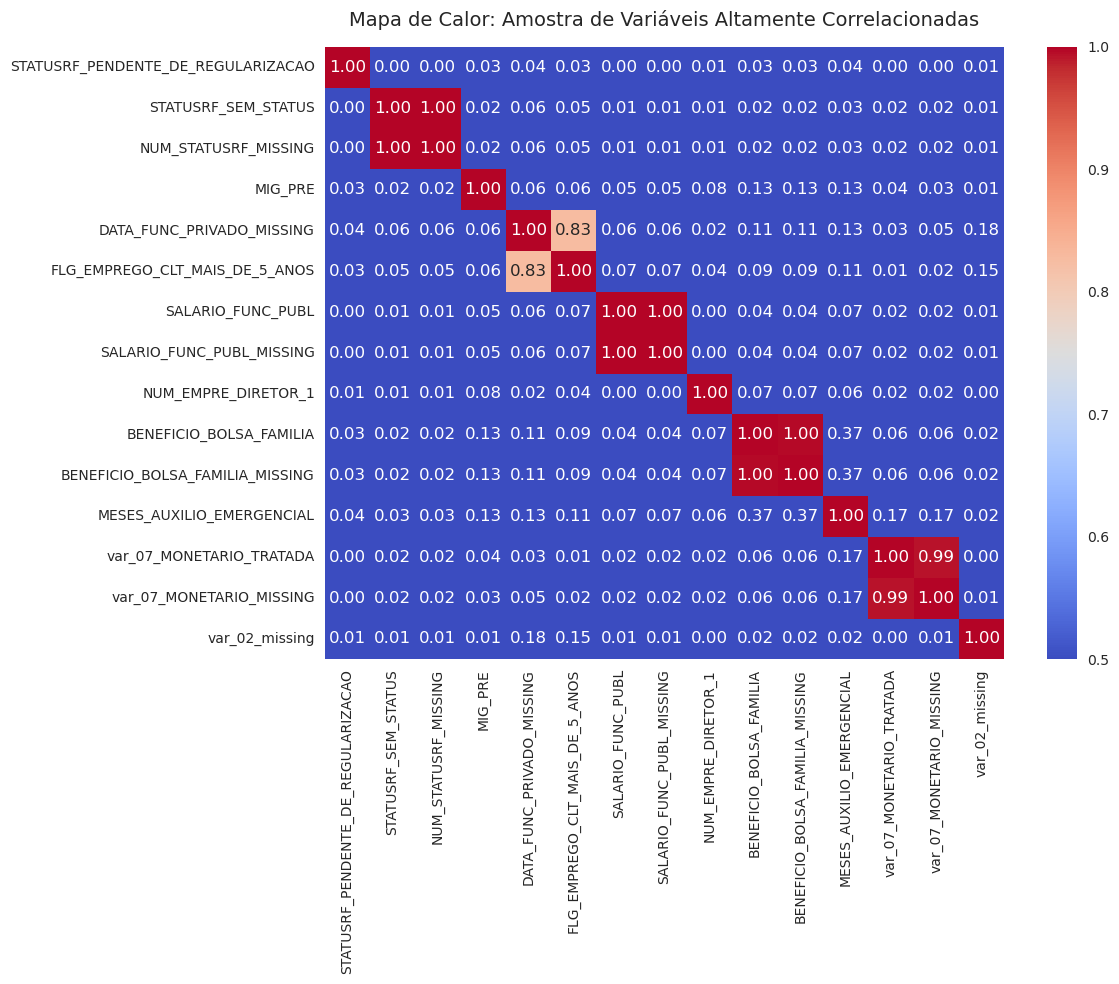


📋 Lista de Colineares Sugeridas para Exclusão (Verifique o SHAP antes de excluir):
['STATUSRF_PENDENTE_DE_REGULARIZACAO', 'STATUSRF_SEM_STATUS', 'NUM_STATUSRF_MISSING', 'MIG_PRE', 'DATA_FUNC_PRIVADO_MISSING', 'FLG_EMPREGO_CLT_MAIS_DE_5_ANOS', 'SALARIO_FUNC_PUBL', 'SALARIO_FUNC_PUBL_MISSING', 'NUM_EMPRE_DIRETOR_1', 'BENEFICIO_BOLSA_FAMILIA', 'BENEFICIO_BOLSA_FAMILIA_MISSING', 'MESES_AUXILIO_EMERGENCIAL', 'var_07_MONETARIO_TRATADA', 'var_07_MONETARIO_MISSING', 'var_02_missing', 'var_26', 'var_27', 'var_28', 'var_29', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_36', 'var_37', 'var_38', 'var_39', 'var_40', 'var_41', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_48', 'var_49', 'var_50', 'var_51', 'var_52', 'var_53', 'var_54', 'var_55', 'var_56', 'var_57', 'var_58', 'var_59', 'var_60', 'var_61', 'var_62', 'var_63', 'var_64', 'var_65', 'var_66', 'var_67', 'var_68', 'var_69', 'var_70', 'var_71', 'var_72', 'var_73', 'var_74', 'var_75', 'var_76', 'var_77'

In [13]:
# ==========================================
# 6. ANÁLISE DE COLINEARIDADE (FILTRO DE REDUNDÂNCIA)
# ==========================================
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os

print("--- INICIANDO ANÁLISE DE COLINEARIDADE (ABT FINAL) ---")

# CORREÇÃO: Declaramos a lista de exclusão aqui. 
# Se você já decidiu quais variáveis jogar fora, coloque os nomes aqui dentro! Ex: ['var_26', 'var_27']
features_excluir = [] 

# Pegamos as features que entraram na última etapa e excluímos as que você já limpou
features_finais = [f for f in features_por_etapa['abt-final'] if f not in features_excluir]

# Usamos apenas o Treino para não vazar informação do Teste/OOT
df_treino_final = df_abt_pandas[(df_abt_pandas[FLAG_OOT] == 0) & (df_abt_pandas[FLAG_CONTROLE] == 0)]

# Amostra de 50.000 linhas para o cálculo ser instantâneo
amostra_corr = df_treino_final[features_finais]

# Calcula a matriz de correlação de Spearman (ideal para crédito/não-linear)
corr_matrix = amostra_corr.corr(method='spearman').abs()

# Pega o triângulo superior da matriz para não contar a mesma dupla duas vezes
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Encontra colunas com correlação acima de 85%
limite_colinearidade = 0.85
colineares = [column for column in upper.columns if any(upper[column] > limite_colinearidade)]

print(f"⚠️ Encontramos {len(colineares)} variáveis altamente colineares (> {limite_colinearidade*100}%).")

# Plot do Mapa de Calor (Amostra das 15 primeiras colineares para não poluir a tela)
if len(colineares) > 0:
    
    plt.figure(figsize=(12, 10))
    cols_to_plot = colineares[:15] 
    sns.heatmap(corr_matrix.loc[cols_to_plot, cols_to_plot], annot=True, cmap='coolwarm', fmt=".2f", vmin=0.5, vmax=1)
    plt.title("Mapa de Calor: Amostra de Variáveis Altamente Correlacionadas", fontsize=14, pad=15)
    plt.tight_layout()
    
    # Se você definiu a pasta de gráficos no Bloco 5, ele salva. Se não, apenas ignora.
    if 'caminho_pasta_graficos' in locals() and caminho_pasta_graficos:
        plt.savefig(os.path.join(caminho_pasta_graficos, '06_matriz_colinearidade.png'), dpi=300, bbox_inches='tight')
    plt.show()

# Imprime a lista completa para você poder copiar e colar na sua regra de exclusão
print("\n📋 Lista de Colineares Sugeridas para Exclusão (Verifique o SHAP antes de excluir):")
print(colineares)

In [14]:
# ==========================================
# 7.5 EXTRAÇÃO DAS VARIÁVEIS MAIS IMPORTANTES
# ==========================================
import pandas as pd

print("--- RANKING MATEMÁTICO PARA SELEÇÃO DE FEATURES ---")

# 1. Extrai a importância nativa do modelo XGBoost já treinado
importancias = modelo_final_treinado.feature_importances_
nomes_features = modelo_final_treinado.feature_names_in_

# 2. Cria um DataFrame organizado do maior para o menor peso
df_ranking = pd.DataFrame({
    'Variavel': nomes_features,
    'Peso_Importancia': importancias
}).sort_values(by='Peso_Importancia', ascending=False).reset_index(drop=True)

# 3. Calcula a importância acumulada 
# (Útil para saber, por exemplo, quantas features somam 90% da inteligência do modelo)
df_ranking['Importancia_Acumulada'] = df_ranking['Peso_Importancia'].cumsum()

# 4. Definindo a linha de corte (Vamos pegar as Top 30 como exemplo)
TOP_N = 100
df_top_n = df_ranking.head(TOP_N)

# 5. Extraindo a lista limpa para você usar no código
top_features_lista = df_top_n['Variavel'].tolist()

print(f"\n🏆 As {TOP_N} Variáveis que mais movem o ponteiro do risco:")
display(df_top_n.style.background_gradient(subset=['Peso_Importancia'], cmap='Blues')
                    .format({'Peso_Importancia': '{:.4f}', 'Importancia_Acumulada': '{:.4f}'}))

print("\n📋 Copie a lista exata abaixo para treinar a sua versão final super leve:")
print("="*80)
print(f"features_selecionadas = {top_features_lista}")
print("="*80)

--- RANKING MATEMÁTICO PARA SELEÇÃO DE FEATURES ---

🏆 As 100 Variáveis que mais movem o ponteiro do risco:


,Variavel,Peso_Importancia,Importancia_Acumulada
0,SCORE_02,0.2044,0.2044
1,QTD_CARTAO_I4,0.0221,0.2265
2,SCORE_01,0.0211,0.2476
3,VAL_TICKET_MEDIO_REAL,0.0191,0.2667
4,PCT_MOMENTUM_RECARGA_30D,0.0157,0.2824
5,QTD_PLATAFORMA_CONTROLE,0.0135,0.2959
6,PCT_DEPENDENCIA_SOS,0.0124,0.3083
7,QTD_CARTAO_PY,0.0111,0.3195
8,VAL_TOTAL_PAG_FATURA,0.0108,0.3303
9,QTD_BANCO_NT1,0.0106,0.3409



📋 Copie a lista exata abaixo para treinar a sua versão final super leve:
features_selecionadas = ['SCORE_02', 'QTD_CARTAO_I4', 'SCORE_01', 'VAL_TICKET_MEDIO_REAL', 'PCT_MOMENTUM_RECARGA_30D', 'QTD_PLATAFORMA_CONTROLE', 'PCT_DEPENDENCIA_SOS', 'QTD_CARTAO_PY', 'VAL_TOTAL_PAG_FATURA', 'QTD_BANCO_NT1', 'QTD_ORIGEM_CHIPPRE_R_30', 'var_85', 'VAL_REAL_U30D', 'VAL_REAL_U31_90D', 'QTD_CARTAO_IA', 'QTD_PLANO_PRE_PAGO_LEGADO', 'MIG_Aquisicao', 'VAL_MEDIA_RECARGA', 'QTD_STAT_FAT_C', 'QTD_CELULARES_RECARREGADOS', 'var_78', 'var_90', 'QTD_ALOC_PYM', 'var_88', 'QTD_CARTAO_IW', 'var_26', 'var_84', 'QTD_CANAL_BANCOS_TRADICIONAL', 'var_80', 'var_76', 'QTD_TIPO_RECAR_N_O_DETERMINADO', 'MIG_PRE', 'QTD_PLANO_PLANO_CONTROLE', 'QTD_PLATAFORMA_CONTROLE_FACIL', 'QTD_PERFIL_ATRASO_ADIANTADO', 'QTD_PLANO_PRE_PAGO_CORE', 'QTD_CARTAO_AX', 'QTD_TURNO_MADRUGADA', 'QTD_CARTAO_FV', 'QTD_BANCO_TRADICIONAL', 'var_75', 'var_81', 'QTD_CARTAO_WT', 'BENEFICIO_BOLSA_FAMILIA', 'QTD_MAX_DIAS_ATRASO', 'var_82', 'QTD_CARTAO_G6'

--- INICIANDO TESTE DE ESTRESSE DE VOLUMETRIA ---
🔄 Avaliando modelo com as Top 10 variáveis...
🔄 Avaliando modelo com as Top 15 variáveis...
🔄 Avaliando modelo com as Top 20 variáveis...
🔄 Avaliando modelo com as Top 30 variáveis...
🔄 Avaliando modelo com as Top 40 variáveis...
🔄 Avaliando modelo com as Top 50 variáveis...
🔄 Avaliando modelo com as Top 75 variáveis...
🔄 Avaliando modelo com as Top 80 variáveis...
🔄 Avaliando modelo com as Top 90 variáveis...
🔄 Avaliando modelo com as Top 100 variáveis...

📊 RESULTADO DO TESTE DE ESTRESSE (OOT / Teste):


,Qtd_Variáveis,Gini (%),KS (%),AUC
0,10,44.46,32.87,0.7223
1,15,45.17,33.32,0.7259
2,20,45.50,33.55,0.7275
3,30,45.56,33.63,0.7278
4,40,45.69,33.77,0.7285
5,50,45.85,33.86,0.7292
6,75,45.99,33.99,0.7300
7,80,46.04,34.09,0.7302
8,90,46.04,34.06,0.7302
9,100,46.04,34.08,0.7302


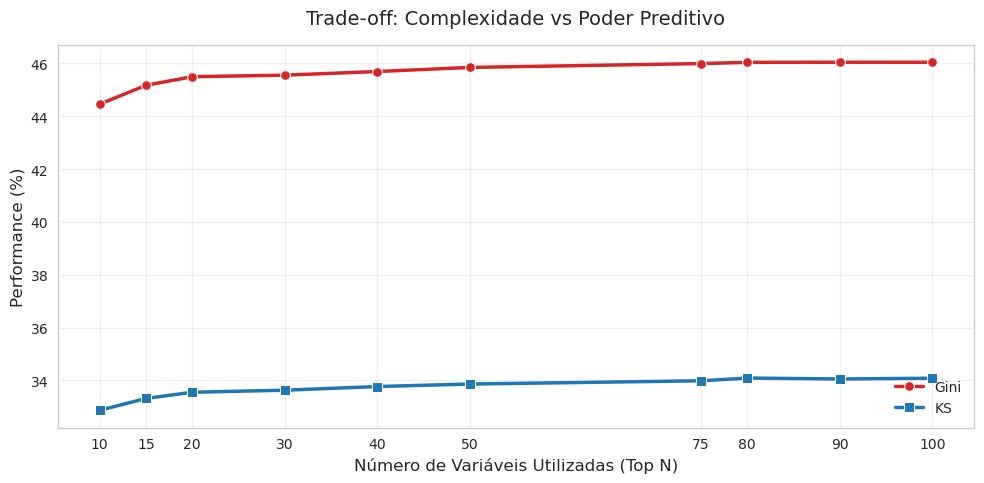

In [15]:
# ==========================================
# 7.6 TESTE DE ESTRESSE: OTIMIZAÇÃO DO CORTE DE VARIÁVEIS
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import os

print("--- INICIANDO TESTE DE ESTRESSE DE VOLUMETRIA ---")

# CORREÇÃO: Resgatando o df_oot para o escopo global do notebook
df_oot = df_abt_pandas[(df_abt_pandas[FLAG_CONTROLE] == 0) & (df_abt_pandas[FLAG_OOT] == 1)]

# 1. Define os cortes que queremos testar (você pode alterar esses números)
cortes_para_testar = [10, 15, 20, 30, 40, 50, 75,80, 90, 100]
resultados_corte = []

# 2. Pega a lista ordenada de features do bloco 7.5 (df_ranking)
features_ordenadas = df_ranking['Variavel'].tolist()

for n_features in cortes_para_testar:
    # Trava de segurança caso o corte seja maior que o total de features
    if n_features > len(features_ordenadas):
        continue
        
    print(f"🔄 Avaliando modelo com as Top {n_features} variáveis...")
    
    # Fatiando apenas as N variáveis mais importantes
    features_da_vez = features_ordenadas[:n_features]
    
    X_train_corte = df_treino_final[features_da_vez]
    y_train_corte = df_treino_final[TARGET]
    X_oot_corte = df_oot[features_da_vez]
    y_oot_corte = df_oot[TARGET]
    
    # Instancia um XGBoost para o teste
    clf_teste = XGBClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=5, 
        objective="binary:logistic", tree_method="hist", 
        random_state=42, n_jobs=-1
    )
    
    # Treina e Prediz
    clf_teste.fit(X_train_corte, y_train_corte)
    proba_oot_corte = clf_teste.predict_proba(X_oot_corte)[:, 1]
    
    # Calcula as métricas usando a sua função do Bloco 2
    metricas = calcular_metricas(y_oot_corte, proba_oot_corte)
    
    resultados_corte.append({
        'Qtd_Variáveis': n_features,
        'Gini (%)': metricas['Gini'],
        'KS (%)': metricas['KS'],
        'AUC': metricas['AUC']
    })

df_teste_cortes = pd.DataFrame(resultados_corte)

# 3. Imprime a Tabela Comparativa
print("\n📊 RESULTADO DO TESTE DE ESTRESSE (OOT / Teste):")
display(df_teste_cortes.style.highlight_max(subset=['Gini (%)', 'KS (%)'], color='lightgreen', axis=0)
                       .format({'Gini (%)': '{:.2f}', 'KS (%)': '{:.2f}', 'AUC': '{:.4f}'}))

# 4. Plota o Gráfico do Ponto de Retorno Decrescente
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_teste_cortes, x='Qtd_Variáveis', y='Gini (%)', marker='o', color='#d62728', lw=2.5, label='Gini')
sns.lineplot(data=df_teste_cortes, x='Qtd_Variáveis', y='KS (%)', marker='s', color='#1f77b4', lw=2.5, label='KS')

plt.title('Trade-off: Complexidade vs Poder Preditivo', fontsize=14, pad=15)
plt.xlabel('Número de Variáveis Utilizadas (Top N)', fontsize=12)
plt.ylabel('Performance (%)', fontsize=12)
plt.xticks(cortes_para_testar)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()

caminho_pasta_graficos = globals().get('caminho_pasta_graficos', 'graficos_hackathon')
if caminho_pasta_graficos:
    os.makedirs(caminho_pasta_graficos, exist_ok=True)
    plt.savefig(os.path.join(caminho_pasta_graficos, '09_tradeoff_variaveis.png'), dpi=300, bbox_inches='tight')
plt.show()

--- SIMULAÇÃO DE IMPACTO FINANCEIRO (BASE DE TESTE / OOT) ---
📉 Baseline Atual (Mercado): Aprova 75% | Inadimplência: 16.00%
-----------------------------------------------------------------
🚀 Simulação com o NOVO MODELO IA (Aprovando os mesmos 75%):
 -> Nova Inadimplência da carteira Claro: 14.15%
 -> Inadimplência da 'nata' que o modelo barrou: 41.39%
-----------------------------------------------------------------
🎉 SUCESSO ABSOLUTO! O modelo reduziu a inadimplência em 1.85 pontos percentuais!
Isso representa milhões de reais protegidos no fluxo de caixa mantendo a meta de vendas.


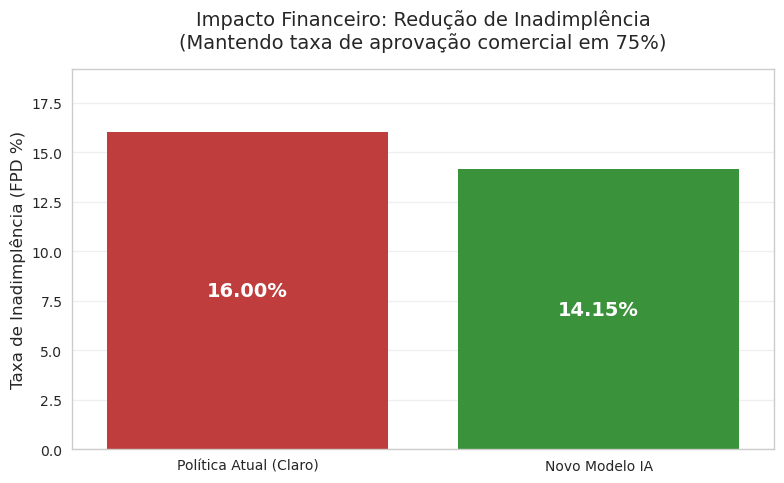

In [16]:
# ==========================================
# 8. SIMULAÇÃO DE NEGÓCIO: IMPACTO FINANCEIRO CLARO
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- SIMULAÇÃO DE IMPACTO FINANCEIRO (BASE DE TESTE / OOT) ---")

# 1. Pega as predições do modelo final treinado para a base OOT
# Usa dinamicamente as features exatas que o modelo aprendeu no Bloco 4/5
features_do_modelo = modelo_final_treinado.feature_names_in_
proba_negocio = modelo_final_treinado.predict_proba(df_oot[features_do_modelo])[:, 1]

df_simulacao = pd.DataFrame({
    'TARGET': df_oot[TARGET],
    'PROBA_CALOTE': proba_negocio
})

# 2. Ordena do MAIOR risco (probabilidade 1) para o MENOR risco (probabilidade 0)
df_simulacao = df_simulacao.sort_values(by='PROBA_CALOTE', ascending=False).reset_index(drop=True)

# 3. Regra de Negócio: A Claro aprova 75%, ou seja, REJEITA os 25% piores.
taxa_reprovacao = 0.25
corte_idx = int(len(df_simulacao) * taxa_reprovacao)

# 4. Divide a base baseada no corte
df_reprovados = df_simulacao.iloc[:corte_idx]
df_aprovados = df_simulacao.iloc[corte_idx:]

# 5. Calcula o calote
calote_historico_claro = 16.0
calote_novo_modelo = df_aprovados['TARGET'].mean() * 100
calote_rejeitados = df_reprovados['TARGET'].mean() * 100
reducao_pontos = calote_historico_claro - calote_novo_modelo

print(f"📉 Baseline Atual (Mercado): Aprova 75% | Inadimplência: {calote_historico_claro:.2f}%")
print("-" * 65)
print(f"🚀 Simulação com o NOVO MODELO IA (Aprovando os mesmos 75%):")
print(f" -> Nova Inadimplência da carteira Claro: {calote_novo_modelo:.2f}%")
print(f" -> Inadimplência da 'nata' que o modelo barrou: {calote_rejeitados:.2f}%")
print("-" * 65)

if calote_novo_modelo < calote_historico_claro:
    print(f"🎉 SUCESSO ABSOLUTO! O modelo reduziu a inadimplência em {reducao_pontos:.2f} pontos percentuais!")
    print("Isso representa milhões de reais protegidos no fluxo de caixa mantendo a meta de vendas.")
else:
    print("⚠️ A inadimplência ficou igual ou acima de 16%.")

# 6. Gráfico de Impacto Executivo
plt.figure(figsize=(8, 5))
barras = sns.barplot(
    x=['Política Atual (Claro)', 'Novo Modelo IA'],
    y=[calote_historico_claro, calote_novo_modelo],
    palette=['#d62728', '#2ca02c']
)

# Coloca a porcentagem no meio da barra
for p in barras.patches:
    barras.annotate(f'{p.get_height():.2f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                    ha='center', va='center', fontsize=14, fontweight='bold', color='white')

plt.title('Impacto Financeiro: Redução de Inadimplência\n(Mantendo taxa de aprovação comercial em 75%)', fontsize=14, pad=15)
plt.ylabel('Taxa de Inadimplência (FPD %)', fontsize=12)
plt.ylim(0, max(calote_historico_claro, calote_novo_modelo) * 1.2)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

caminho_pasta_graficos = globals().get('caminho_pasta_graficos', 'graficos_hackathon')
if caminho_pasta_graficos:
    os.makedirs(caminho_pasta_graficos, exist_ok=True)
    plt.savefig(os.path.join(caminho_pasta_graficos, '10_impacto_financeiro.png'), dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# ==========================================
# 9. SINTONIA FINA (GRID SEARCH) - TOP 80 FEATURES
# ==========================================
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import time

print("--- INICIANDO GRID SEARCH (OTIMIZAÇÃO DE HIPERPARÂMETROS) ---")

# 1. Selecionando as Top 80 variáveis do nosso ranking
TOP_N = 80
features_top75 = df_ranking['Variavel'].head(TOP_N).tolist()

X_train_75 = df_treino_final[features_top75]
y_train = df_treino_final[TARGET]
X_oot_75 = df_oot[features_top75]
y_oot = df_oot[TARGET]

print(f"Base fatiada com sucesso: {X_train_75.shape[1]} variáveis selecionadas.")

# 2. Definindo a grade de parâmetros (Focada para otimização rápida e eficiente)
param_grid = {
    'max_depth': [3, 5, 7],            # Profundidade da árvore (controla overfitting)
    'learning_rate': [0.01, 0.05, 0.1], # Tamanho do passo de aprendizado
    'n_estimators': [100, 200, 300],    # Quantidade de árvores
    'subsample': [0.8, 1.0]             # Fração de linhas usadas por árvore (0.8 ajuda a generalizar)
}

# 3. Instanciando o modelo base
xgb_base = XGBClassifier(
    objective="binary:logistic",
    tree_method="hist", # Método 'hist' é essencial para ser rápido em bases grandes
    random_state=42,
    n_jobs=-1
)

# 4. Configurando o Grid Search (CV=3 para economizar tempo de processamento)
# Ele vai testar as combinações usando a métrica 'roc_auc' (ideal para risco de crédito)
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3, 
    verbose=2, # Mostra o progresso na tela
    n_jobs=-1  # Usa todos os núcleos do seu processador
)

total_fits = len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['n_estimators']) * len(param_grid['subsample']) * 3
print(f"\nIniciando treinamento de {total_fits} combinações...")
start_time = time.time()

# Roda o treinamento
grid_search.fit(X_train_75, y_train)

end_time = time.time()
print(f"\n✅ Grid Search concluído em {(end_time - start_time)/60:.2f} minutos.")

# 5. Capturando os Resultados
modelo_campeao_tunado = grid_search.best_estimator_

print("\n" + "🏆"*20)
print(" MELHORES PARÂMETROS ENCONTRADOS:")
for param, valor in grid_search.best_params_.items():
    print(f" -> {param}: {valor}")
print("🏆"*20)

# 6. Avaliação final no OOT com o modelo tunado
proba_oot_tunado = modelo_campeao_tunado.predict_proba(X_oot_75)[:, 1]
metricas_tunado = calcular_metricas(y_oot, proba_oot_tunado)

print("\n🚀 PERFORMANCE FINAL DO MODELO TUNADO (Base OOT):")
print(f"KS: {metricas_tunado['KS']:.2f}% | Gini: {metricas_tunado['Gini']:.2f}% | AUC: {metricas_tunado['AUC']:.4f}")

--- INICIANDO GRID SEARCH (OTIMIZAÇÃO DE HIPERPARÂMETROS) ---
Base fatiada com sucesso: 80 variáveis selecionadas.

Iniciando treinamento de 162 combinações...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8; total time=  10.5s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=200, subsample=1.0; total time=  15.4s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=100, subsample=0.8; total time=  14.0s

✅ Grid Search concluído em 5.91 minutos.

🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆
 MELHORES PARÂMETROS ENCONTRADOS:
 -> learning_rate: 0.05
 -> max_depth: 7
 -> n_estimators: 300
 -> subsample: 0.8
🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆🏆

🚀 PERFORMANCE FINAL DO MODELO TUNADO (Base OOT):
KS: 34.56% | Gini: 46.70% | AUC: 0.7335


--- RECUPERANDO BASES E INICIANDO TREINAMENTO DEFINITIVO ---
✔️ Utilizando as 80 features mais importantes.
✅ CSV de treino salvo em: artefatos_modelo_final/treino_final.csv
✅ CSV de OOT salvo em: artefatos_modelo_final/oot_final.csv
⏳ Treinando o algoritmo com a configuração otimizada...
✅ Treinamento concluído com sucesso!
✅ Modelo salvo em: artefatos_modelo_final/modelo_definitivo.pkl

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 DOSSIÊ VISUAL FINAL DO MODELO CAMPEÃO
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★


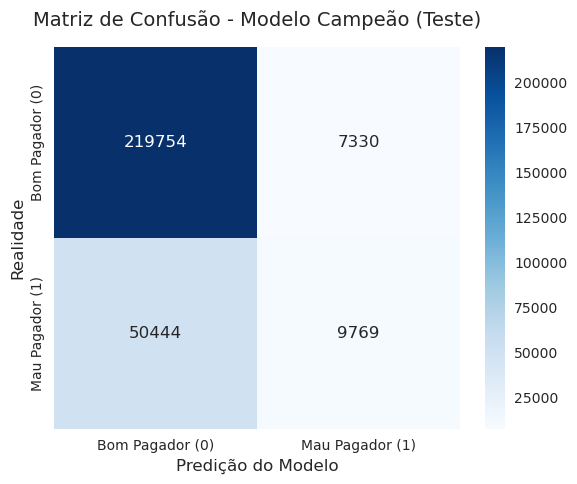

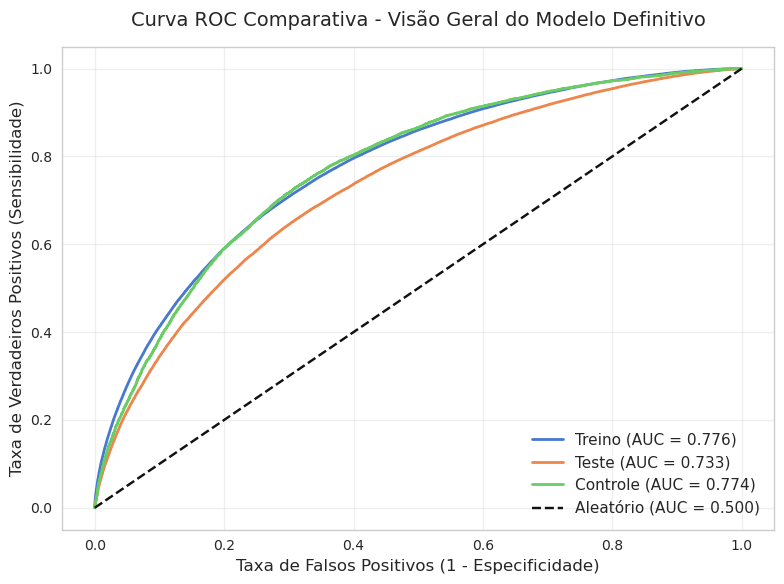

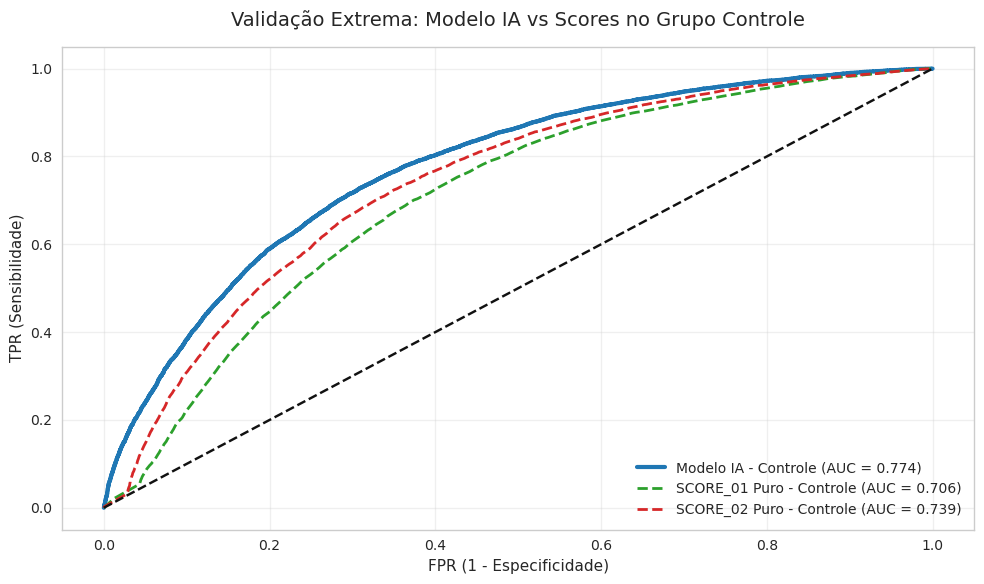

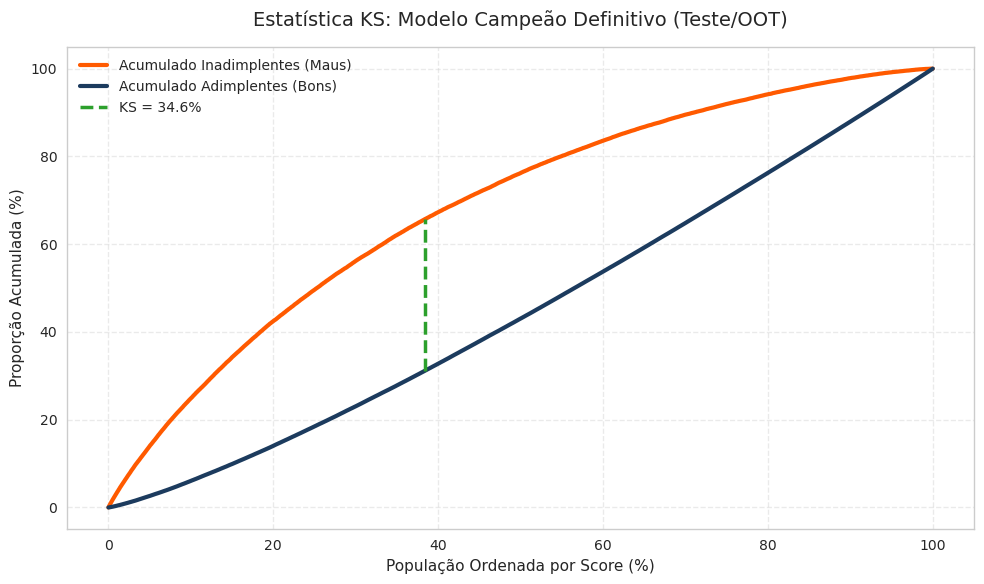


 📊 RESUMO DE MÉTRICAS DO MODELO CAMPEÃO (BASE DE TESTE)


,KS,Gini,AUC,F1,Recall,Precision
0,34.56%,46.70%,0.7335,0.2527,0.1622,0.5713


In [18]:
# ==========================================
# 10. TREINAMENTO DO MODELO CAMPEÃO DEFINITIVO (ABT) E DOSSIÊ VISUAL
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import pandas as pd
import numpy as np
import os
import joblib
from IPython.display import display

print("--- RECUPERANDO BASES E INICIANDO TREINAMENTO DEFINITIVO ---")

# 0. RECUPERAÇÃO DE MEMÓRIA (Evita o erro de variável não definida)
df_controle = df_abt_pandas[df_abt_pandas[FLAG_CONTROLE] == 1].copy()
df_modelagem = df_abt_pandas[df_abt_pandas[FLAG_CONTROLE] == 0].copy()
df_oot = df_modelagem[df_modelagem[FLAG_OOT] == 1].copy()
df_treino_final = df_modelagem[df_modelagem[FLAG_OOT] == 0].copy()

# 1. Definindo as Top Variáveis 
TOP_N_FINAL = 80
# Se der erro no df_ranking aqui, comente a linha abaixo e cole sua lista na mão:
# features_finais_campeas = ['sua_var1', 'sua_var2', ...]
features_finais_campeas = df_ranking['Variavel'].head(TOP_N_FINAL).tolist()

print(f"✔️ Utilizando as {TOP_N_FINAL} features mais importantes.")

# 2. Separando as bases (Fatiando apenas as colunas selecionadas)
X_train_final = df_treino_final[features_finais_campeas]
y_train_final = df_treino_final[TARGET]

X_oot_final = df_oot[features_finais_campeas]
y_oot_final = df_oot[TARGET]

X_ctrl_final = df_controle[features_finais_campeas]
y_ctrl_final = df_controle[TARGET]


# ==========================================
# 2.1 SALVANDO AS BASES FINAIS EM CSV
# ==========================================
pasta_saida = "artefatos_modelo_final"
os.makedirs(pasta_saida, exist_ok=True)

df_csv_treino_final = pd.concat(
    [X_train_final, y_train_final.rename(TARGET)],
    axis=1
)

df_csv_oot_final = pd.concat(
    [X_oot_final, y_oot_final.rename(TARGET)],
    axis=1
)

caminho_csv_treino = os.path.join(pasta_saida, "treino_final.csv")
caminho_csv_oot = os.path.join(pasta_saida, "oot_final.csv")

df_csv_treino_final.to_csv(caminho_csv_treino, index=False, encoding="utf-8")
df_csv_oot_final.to_csv(caminho_csv_oot, index=False, encoding="utf-8")

print(f"✅ CSV de treino salvo em: {caminho_csv_treino}")
print(f"✅ CSV de OOT salvo em: {caminho_csv_oot}")

# 3. Instanciando o XGBoost com os MELHORES parâmetros do Grid Search
modelo_campeao_definitivo = XGBClassifier(
    learning_rate=0.05,
    max_depth=7,
    n_estimators=300,
    subsample=0.8,
    objective="binary:logistic",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# 4. Treinamento
print("⏳ Treinando o algoritmo com a configuração otimizada...")
modelo_campeao_definitivo.fit(X_train_final, y_train_final)
print("✅ Treinamento concluído com sucesso!")

# ==========================================
# 4.1 SALVANDO O MODELO TREINADO EM PKL
# ==========================================
caminho_modelo_pkl = os.path.join(pasta_saida, "modelo_definitivo.pkl")
joblib.dump(modelo_campeao_definitivo, caminho_modelo_pkl)

print(f"✅ Modelo salvo em: {caminho_modelo_pkl}")

# 5. Predições
proba_train = modelo_campeao_definitivo.predict_proba(X_train_final)[:, 1]
proba_oot = modelo_campeao_definitivo.predict_proba(X_oot_final)[:, 1]
proba_ctrl = modelo_campeao_definitivo.predict_proba(X_ctrl_final)[:, 1]

# 6. Calculando todas as métricas no OOT
metricas_final = calcular_metricas(y_oot_final, proba_oot)
caminho_pasta_graficos = globals().get('caminho_pasta_graficos', None)

print("\n" + "★"*60)
print(" DOSSIÊ VISUAL FINAL DO MODELO CAMPEÃO")
print("★"*60)

# ---------------------------------------------------------
# GRÁFICO 1: Matriz de Confusão
# ---------------------------------------------------------
plotar_matriz_confusao(
    y_oot_final, proba_oot, 
    titulo="Matriz de Confusão - Modelo Campeão (Teste)", 
    caminho_salvar=caminho_pasta_graficos
)

# ---------------------------------------------------------
# GRÁFICO 2: Curva ROC Comparativa Geral (Treino x Teste x Controle)
# ---------------------------------------------------------
plotar_roc_comparativa(
    modelo_campeao_definitivo,
    X_train_final, y_train_final,
    X_oot_final, y_oot_final,
    X_ctrl_final, y_ctrl_final,
    titulo=f"Visão Geral do Modelo Definitivo",
    caminho_salvar=caminho_pasta_graficos
)

# ---------------------------------------------------------
# GRÁFICO 3: ROC Controle (Modelo vs Scores de Mercado)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
fpr_mod, tpr_mod, _ = roc_curve(y_ctrl_final, proba_ctrl)
auc_mod = roc_auc_score(y_ctrl_final, proba_ctrl)
plt.plot(fpr_mod, tpr_mod, label=f'Modelo IA - Controle (AUC = {auc_mod:.3f})', color='#1f77b4', lw=3)

for score_col, cor in [('SCORE_01', '#2ca02c'), ('SCORE_02', '#d62728')]:
    if score_col in df_controle.columns:
        sc_puro = df_controle[score_col]
        if roc_auc_score(y_ctrl_final, sc_puro) < 0.5: sc_puro = -sc_puro
        fpr_sc, tpr_sc, _ = roc_curve(y_ctrl_final, sc_puro)
        auc_sc = roc_auc_score(y_ctrl_final, sc_puro)
        plt.plot(fpr_sc, tpr_sc, label=f'{score_col} Puro - Controle (AUC = {auc_sc:.3f})', linestyle='--', color=cor, lw=2)

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Validação Extrema: Modelo IA vs Scores no Grupo Controle', fontsize=14, pad=15)
plt.xlabel('FPR (1 - Especificidade)')
plt.ylabel('TPR (Sensibilidade)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

if caminho_pasta_graficos:
    plt.savefig(os.path.join(caminho_pasta_graficos, '10_roc_controle_campeao.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 4: KS Acumulado e Corte Ótimo (OOT)
# ---------------------------------------------------------
df_ks_plot = pd.DataFrame({'target': y_oot_final, 'proba': proba_oot}).sort_values(by='proba', ascending=False).reset_index(drop=True)
df_ks_plot['cum_bads'] = df_ks_plot['target'].cumsum() / df_ks_plot['target'].sum() * 100
df_ks_plot['cum_goods'] = (1 - df_ks_plot['target']).cumsum() / (len(df_ks_plot) - df_ks_plot['target'].sum()) * 100
df_ks_plot['ks_dist'] = np.abs(df_ks_plot['cum_bads'] - df_ks_plot['cum_goods'])

ks_max = df_ks_plot['ks_dist'].max()
ks_idx = df_ks_plot['ks_dist'].idxmax()

plt.figure(figsize=(10, 6))
eixo_x = np.arange(1, len(df_ks_plot) + 1) / len(df_ks_plot) * 100
plt.plot(eixo_x, df_ks_plot['cum_bads'], label='Acumulado Inadimplentes (Maus)', color='#ff5a00', lw=3)
plt.plot(eixo_x, df_ks_plot['cum_goods'], label='Acumulado Adimplentes (Bons)', color='#1c3b5e', lw=3)
plt.vlines(x=(ks_idx/len(df_ks_plot))*100, ymin=df_ks_plot.loc[ks_idx, 'cum_goods'], ymax=df_ks_plot.loc[ks_idx, 'cum_bads'], color='#2ca02c', linestyle='--', lw=2.5, label=f'KS = {ks_max:.1f}%')

plt.title('Estatística KS: Modelo Campeão Definitivo (Teste/OOT)', fontsize=14, pad=15)
plt.xlabel('População Ordenada por Score (%)')
plt.ylabel('Proporção Acumulada (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()

if caminho_pasta_graficos:
    plt.savefig(os.path.join(caminho_pasta_graficos, '11_ks_campeao_definitivo.png'), dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# TABELA FINAL DE MÉTRICAS
# ---------------------------------------------------------
print("\n" + "="*60)
print(" 📊 RESUMO DE MÉTRICAS DO MODELO CAMPEÃO (BASE DE TESTE)")
print("="*60)

# Convertendo o dicionário de métricas em um DataFrame elegante
df_metricas_finais = pd.DataFrame([metricas_final])
# Reordenando as colunas para dar destaque ao KS e Gini
df_metricas_finais = df_metricas_finais[['KS', 'Gini', 'AUC', 'F1', 'Recall', 'Precision']]

display(df_metricas_finais.style.format({
    'KS': '{:.2f}%', 
    'Gini': '{:.2f}%', 
    'AUC': '{:.4f}', 
    'F1': '{:.4f}', 
    'Recall': '{:.4f}', 
    'Precision': '{:.4f}'
}).set_properties(**{'text-align': 'center', 'font-size': '14px', 'font-weight': 'bold'}))

--- SIMULAÇÃO DE IMPACTO FINANCEIRO (CENÁRIO AGRESSIVO) ---
📉 Baseline Atual (Claro): Aprova 73% | Inadimplência: 21.30%
---------------------------------------------------------------------------
🚀 Simulação NOVO MODELO IA (Aprovando 77% - Mais receita para a empresa):
 -> Nova Inadimplência da carteira Claro: 14.68%
 -> Inadimplência da 'nata' que o modelo barrou: 43.22%
---------------------------------------------------------------------------
🎉 SUCESSO ABSOLUTO! O modelo aprovou 4% MAIS clientes e ainda reduziu a inadimplência em 6.62 pontos!
O argumento para a banca: 'Nós geramos crescimento de vendas com redução de risco operacinal.'


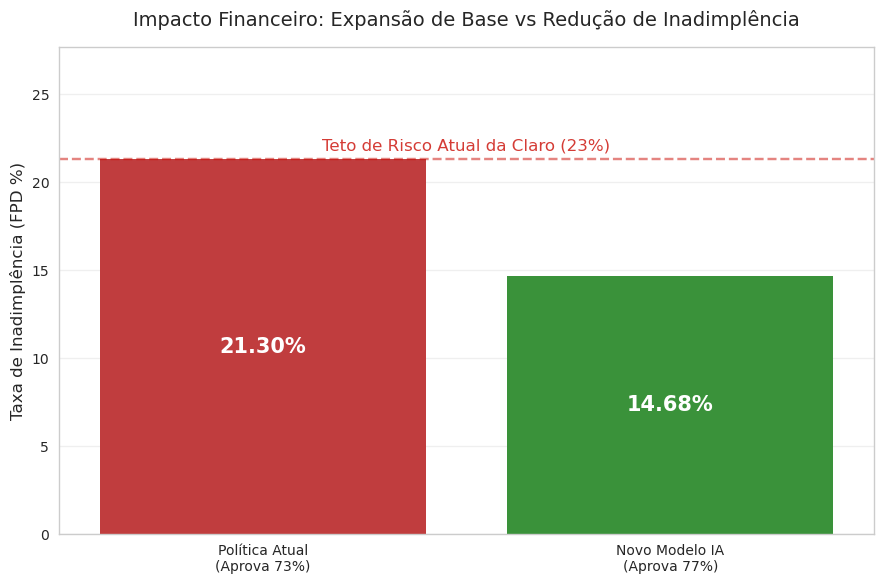

In [19]:
# ==========================================
# 11. SIMULAÇÃO DE NEGÓCIO:
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- SIMULAÇÃO DE IMPACTO FINANCEIRO (CENÁRIO AGRESSIVO) ---")

# 1. Escorando a base OOT com o Modelo Campeão Definitivo
# Usamos a lista de features finais que você definiu no Bloco 10
proba_negocio = modelo_campeao_definitivo.predict_proba(df_oot[features_finais_campeas])[:, 1]

df_simulacao = pd.DataFrame({
    'TARGET': df_oot[TARGET],
    'PROBA_CALOTE': proba_negocio
})

# 2. Ordena do MAIOR risco (probabilidade 1) para o MENOR risco (probabilidade 0)
df_simulacao = df_simulacao.sort_values(by='PROBA_CALOTE', ascending=False).reset_index(drop=True)

# 3. Novas Regras de Negócio:
# A Claro hoje aprova 73% (FPD 23%). Você quer testar aprovar 77%.
# Se aprovamos 77%, cortamos (rejeitamos) os 23% piores.
taxa_reprovacao_nova = 0.22 
corte_idx = int(len(df_simulacao) * taxa_reprovacao_nova)

# 4. Divide a base baseada no novo corte
df_reprovados = df_simulacao.iloc[:corte_idx]
df_aprovados = df_simulacao.iloc[corte_idx:]

# 5. Calcula o calote
calote_historico_claro = 21.3
calote_novo_modelo = df_aprovados['TARGET'].mean() * 100
calote_rejeitados = df_reprovados['TARGET'].mean() * 100
reducao_pontos = calote_historico_claro - calote_novo_modelo

print(f"📉 Baseline Atual (Claro): Aprova 73% | Inadimplência: {calote_historico_claro:.2f}%")
print("-" * 75)
print(f"🚀 Simulação NOVO MODELO IA (Aprovando 77% - Mais receita para a empresa):")
print(f" -> Nova Inadimplência da carteira Claro: {calote_novo_modelo:.2f}%")
print(f" -> Inadimplência da 'nata' que o modelo barrou: {calote_rejeitados:.2f}%")
print("-" * 75)

if calote_novo_modelo < calote_historico_claro:
    print(f"🎉 SUCESSO ABSOLUTO! O modelo aprovou 4% MAIS clientes e ainda reduziu a inadimplência em {reducao_pontos:.2f} pontos!")
    print("O argumento para a banca: 'Nós geramos crescimento de vendas com redução de risco operacinal.'")
else:
    print("⚠️ A inadimplência ficou igual ou acima de 23%. Tentar aprovar 77% pode ser muito arriscado.")

# 6. Gráfico de Impacto Executivo

plt.figure(figsize=(9, 6))
barras = sns.barplot(
    x=['Política Atual\n(Aprova 73%)', 'Novo Modelo IA\n(Aprova 77%)'],
    y=[calote_historico_claro, calote_novo_modelo],
    palette=['#d62728', '#2ca02c']
)

# Coloca a porcentagem no meio da barra
for p in barras.patches:
    barras.annotate(f'{p.get_height():.2f}%',
                    (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                    ha='center', va='center', fontsize=15, fontweight='bold', color='white')

plt.title('Impacto Financeiro: Expansão de Base vs Redução de Inadimplência', fontsize=14, pad=15)
plt.ylabel('Taxa de Inadimplência (FPD %)', fontsize=12)
plt.ylim(0, max(calote_historico_claro, calote_novo_modelo) * 1.3)

# Adiciona uma linha pontilhada mostrando o limite de risco atual da Claro
plt.axhline(y=calote_historico_claro, color='r', linestyle='--', alpha=0.5)
plt.text(0.5, calote_historico_claro + 0.5, 'Teto de Risco Atual da Claro (23%)', color='r', ha='center', alpha=0.8)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

caminho_pasta_graficos = globals().get('caminho_pasta_graficos', None)
if caminho_pasta_graficos:
    os.makedirs(caminho_pasta_graficos, exist_ok=True)
    plt.savefig(os.path.join(caminho_pasta_graficos, '12_simulacao_negocio_77pct.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ==========================================
# 12. ESTABILIDADE TEMPORAL (MÉTRICAS POR SAFRA)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print("--- INICIANDO ANÁLISE DE ESTABILIDADE POR SAFRA ---")

# ⚠️ COLOQUE AQUI O NOME DA SUA COLUNA DE SAFRA/MÊS (ex: 'SAFRA', 'DT_REF', 'MES_REFERENCIA')
COLUNA_SAFRA = 'SAFRA'  # <--- Altere isso se necessário!

# Verifica se a coluna existe na base
if COLUNA_SAFRA not in df_abt_pandas.columns:
    print(f"❌ ERRO: A coluna '{COLUNA_SAFRA}' não foi encontrada na base. Altere o nome no código acima.")
else:
    # 1. Vamos usar a base de modelagem (Treino + OOT, ignorando o Controle)
    df_safra = df_abt_pandas[df_abt_pandas[FLAG_CONTROLE] == 0].copy()
    
    # 2. Escora a base inteira com o modelo campeão
    print("⏳ Calculando predições para toda a base histórica e futura...")
    X_safra = df_safra[features_finais_campeas]
    df_safra['PROBA_MODELO'] = modelo_campeao_definitivo.predict_proba(X_safra)[:, 1]
    
    resultados_safra = []
    
    # 3. Agrupa por Safra e calcula as métricas mês a mês
    safras_ordenadas = sorted(df_safra[COLUNA_SAFRA].dropna().unique())
    
    for safra in safras_ordenadas:
        df_mes = df_safra[df_safra[COLUNA_SAFRA] == safra]
        y_true_mes = df_mes[TARGET]
        y_proba_mes = df_mes['PROBA_MODELO']
        
        # Só calcula se houver os dois tipos de clientes (Bons e Maus) naquele mês
        if len(y_true_mes.unique()) > 1:
            metricas_mes = calcular_metricas(y_true_mes, y_proba_mes)
            
            # Identifica se essa safra é predominantemente Treino ou Teste(OOT)
            flag_oot = "OOT (Teste)" if df_mes[FLAG_OOT].mean() > 0.5 else "Treino"
            
            resultados_safra.append({
                'Safra': safra,
                'Volume_Clientes': len(df_mes),
                'Taxa_Maus (%)': y_true_mes.mean() * 100,
                'KS (%)': metricas_mes['KS'],
                'Gini (%)': metricas_mes['Gini'],
                'Base': flag_oot
            })
            
    df_resultados_safra = pd.DataFrame(resultados_safra)
    
    # 4. Imprime a Tabela Elegante
    print("\n📊 RESULTADOS DETALHADOS POR SAFRA:")
    display(df_resultados_safra.style.format({
        'Volume_Clientes': '{:,.0f}',
        'Taxa_Maus (%)': '{:.2f}%',
        'KS (%)': '{:.2f}%',
        'Gini (%)': '{:.2f}%'
    }).background_gradient(subset=['KS (%)', 'Gini (%)'], cmap='Blues'))

    # 5. Gráfico de Estabilidade (O que a Banca quer ver)
    
    plt.figure(figsize=(12, 6))
    
    # Plota as linhas de KS e Gini
    sns.lineplot(data=df_resultados_safra, x='Safra', y='Gini (%)', marker='o', color='#d62728', lw=3, label='Gini')
    sns.lineplot(data=df_resultados_safra, x='Safra', y='KS (%)', marker='s', color='#1f77b4', lw=3, label='KS')
    
    # Pinta o fundo de cinza para os meses que são OOT (para mostrar que lá o modelo não treinou)
    safras_oot = df_resultados_safra[df_resultados_safra['Base'] == 'OOT (Teste)']['Safra'].tolist()
    if len(safras_oot) > 0:
        plt.axvspan(safras_oot[0], safras_oot[-1], color='gray', alpha=0.15, label='Período OOT (Futuro)')
        plt.axvline(x=safras_oot[0], color='k', linestyle='--', alpha=0.7)

    # Adiciona os valores em cima dos pontos do KS
    for i, row in df_resultados_safra.iterrows():
        plt.text(i, row['KS (%)'] + 1, f"{row['KS (%)']:.1f}", ha='center', fontsize=9, fontweight='bold', color='#1f77b4')

    plt.title('Estabilidade do Modelo ao Longo do Tempo (Visão por Safra)', fontsize=15, pad=15)
    plt.xlabel('Safra (Mês/Ano)', fontsize=12)
    plt.ylabel('Performance (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.ylim(0, max(df_resultados_safra['Gini (%)'].max() + 10, 60))
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    caminho_pasta_graficos = globals().get('caminho_pasta_graficos', None)
    if caminho_pasta_graficos:
        import os
        plt.savefig(os.path.join(caminho_pasta_graficos, '13_estabilidade_por_safra.png'), dpi=300, bbox_inches='tight')
    plt.show()

--- INICIANDO ANÁLISE DE ESTABILIDADE POR SAFRA ---
⏳ Calculando predições para toda a base histórica e futura...
[CV] END learning_rate=0.01, max_depth=5, n_estimators=200, subsample=0.8; total time=  24.0s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.8; total time=  17.4s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=200, subsample=0.8; total time=  30.4s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=300, subsample=1.0; total time=  41.4s
[CV] END learning_rate=0.05, max_depth=5, n_estimators=100, subsample=0.8; total time=  12.4s
[CV] END learning_rate=0.05, max_depth=5, n_estimators=100, subsample=1.0; total time=  11.8s
[CV] END learning_rate=0.05, max_depth=5, n_estimators=300, subsample=0.8; total time=  25.2s
[CV] END learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.8; total time=  22.3s
[CV] END learning_rate=0.05, max_depth=7, n_estimators=300, subsample=1.0; total time=  28.3s
[CV] END learning_rate=0.1, max_depth=3,

,Safra,Volume_Clientes,Taxa_Maus (%),KS (%),Gini (%),Base
0,202410,"145,876",20.08%,40.51%,53.54%,Treino
1,202411,"156,028",21.08%,40.31%,54.00%,Treino
2,202412,"152,639",21.08%,39.24%,52.20%,Treino
3,202501,"156,012",20.99%,39.89%,52.93%,Treino
4,202502,"144,198",20.83%,33.32%,44.50%,OOT (Teste)
5,202503,"149,555",21.16%,34.50%,45.92%,OOT (Teste)
